# E81 · Circular data: directions, times of day and seasons

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: (1) three years of **hourly wind reports from Santa Barbara airport** (ASOS station KSBA, 2021-2023, 26,101 reports; Iowa Environmental Mesonet archive); (2) **camera-trap records from Barro Colorado Island**, Panama (Rowcliffe et al. 2014, figshare, CC BY 4.0): the time of day of 16,282 photographs of an ocelot and five of the animals it may hunt; (3) as a control, the times of 2,917 **Oklahoma earthquakes** of magnitude 3+ (USGS, already used in E07) |
| **You will learn** | Why the arithmetic mean of angles fails, the **mean resultant vector** and its length · four circular distributions side by side: **von Mises, wrapped normal, wrapped Cauchy, projected normal** · what "no pattern" looks like: the Rayleigh test and a Bayesian concentration · **circular-linear regression** with the tan-half link, its two traps (a **wrapped prior** that pins a chain to $\pm\pi$ with zero divergences, and a genuine **second mode** where the link becomes a step) and the fix: the von Mises as an exponential family with a **canonical (natural-parameter) link**, whose log posterior is concave · **circular-circular regression** of wind direction on hour of day and day of year (circular predictors), the **projected normal** and its latent vector, a **mixture of wind regimes** with gates that depend on time · **circular posterior predictive checks**: rose diagrams with bands and circular PIT · LOO and a **held-out year** · **label switching** in von Mises mixtures and how to check r-hat on the density instead · a label-free **log-Fourier density** fitted through its sufficient statistics (trigonometric moments) · the camera-trap **overlap coefficient** with posterior uncertainty, against the kernel estimator and bootstrap · displays: rose diagrams with posterior bands, clock-face plots, a clock of wind arrows, polar spaghetti of mean-direction curves, **circular HDIs drawn as arcs**, overlap plots |

## The setting

Many measurements live on a circle. A wind blows *from* a direction between 0 and 360 degrees, and
359 degrees is next to 1 degree. An animal walks past a camera at a time of day, and 23:59 is next to
00:01. A disease peaks in a season, and December is next to January. The usual toolbox quietly
assumes a line: an average, a normal likelihood, a regression slope, a histogram with two ends. On a
circle each of these can give a confident, wrong answer.

We work with three real datasets, each making a different point:

* **Wind at Santa Barbara.** The airport sits on a coastal plain between the Pacific and the Santa
  Ynez mountains. On a typical day, cool air drains down from the mountains towards the sea at night
  and the sea breeze blows inland in the afternoon. The direction therefore swings through half the
  compass every day, and the swing changes with the season. *How does the wind direction depend on
  wind speed, hour and season, and how sure are we?*
* **Camera traps in a tropical forest.** Ocelots hunt at night. Do their hours overlap with those of
  the agouti (active by day), the paca and the spiny rat (active by night)? The standard answer in
  ecology is an **overlap coefficient** between two activity curves on the 24-hour circle. *How big is
  it and how uncertain?*
* **Earthquakes as a control.** Magnitude 3+ earthquakes in Oklahoma should not care what time it is.
  *What does "no daily pattern" look like, and how does a Bayesian model say so?*

| part | question | tool |
|---|---|---|
| A | Why are angles different? | mean resultant vector, four circular distributions, a null dataset |
| B | What does the Santa Barbara wind do? | calms, rounding, local solar time, rose diagrams by hour |
| C | Does the direction depend on wind speed? | tan-half link, a wrapped prior, a second mode, the canonical link |
| D | How does it depend on hour and season? | von Mises and projected-normal regression, a mixture of regimes, circular PPCs, LOO, a held-out year |
| E | When is an ocelot about, and when are its prey? | von Mises mixtures and label switching, a log-Fourier density, overlap and activity level |

Everything is written with NumPy, SciPy and PyMC; there is no circular-statistics package.

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from matplotlib.patches import FancyArrowPatch
from scipy import special
from scipy.optimize import brentq

from pymc_challenges import data

RANDOM_SEED = 81
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
warnings.filterwarnings("ignore", message=".*sample_stats.*")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 20)
T_START = time.time()

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"   # categorical slots 1-3, fixed order
INK, MUTED, LIGHT = "#0b0b0b", "#8a8984", "#d9d8d3"
TWO_PI = 2 * np.pi


def wrap(a):
    """Angle(s) to (-pi, pi]."""
    return np.angle(np.exp(1j * np.asarray(a)))


def mean_resultant(th, axis=None):
    """Mean direction and mean resultant length of angles in radians."""
    z = np.exp(1j * np.asarray(th)).mean(axis=axis)
    return np.angle(z), np.abs(z)


def A1(k):
    """Mean resultant length of a von Mises with concentration k: I1(k) / I0(k)."""
    return special.i1e(k) / special.i0e(k)


def A1inv(R):
    return brentq(lambda k: A1(k) - R, 1e-9, 1e4) if R > 1e-9 else 0.0


def vm_logpdf(th, e1, e2):
    """von Mises log density in NATURAL parameters: exp(e1 cos th + e2 sin th) / (2 pi I0(|e|))."""
    k = np.hypot(e1, e2)
    return e1 * np.cos(th) + e2 * np.sin(th) - np.log(TWO_PI) - (np.log(special.i0e(k)) + k)


def pn_logpdf(th, m1, m2):
    """Projected normal (identity covariance) log density of the angle of z ~ N((m1, m2), I)."""
    u = m1 * np.cos(th) + m2 * np.sin(th)
    return -np.log(TWO_PI) - 0.5 * (m1 ** 2 + m2 ** 2) + np.log1p(u * np.sqrt(np.pi / 2) * special.erfcx(-u / np.sqrt(2)))


def vm_lp(th, e1, e2):
    """The same von Mises log density as a PyTensor expression."""
    k = pt.sqrt(e1 ** 2 + e2 ** 2)
    return e1 * np.cos(th) + e2 * np.sin(th) - np.log(TWO_PI) - pt.log(pt.i0(k))


def loo_from_ll(ll):
    """PSIS-LOO from a (draws, observations) log-likelihood matrix computed in NumPy."""
    tree = xr.DataTree.from_dict({
        "posterior": xr.Dataset({"d": (("chain", "draw"), np.zeros((1, ll.shape[0])))}),
        "log_likelihood": xr.Dataset({"y": (("chain", "draw", "obs"), ll[None])}),
    })
    res = az.loo(tree, pointwise=True)
    res.log_weights = None
    return res


def circ_hdi(draws, prob=0.94):
    """Shortest arc containing `prob` of the draws (valid when they cover less than a half circle)."""
    c, _ = mean_resultant(draws)
    d = np.sort(wrap(draws - c))
    m = int(np.ceil(prob * len(d)))
    widths = d[m - 1:] - d[:len(d) - m + 1]
    i = np.argmin(widths)
    return c + d[i], c + d[i + m - 1], c


def compass(ax, labels=True):
    """Polar axes as a compass: north up, clockwise, degrees FROM which the wind blows."""
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"] if labels else [])
    ax.grid(alpha=0.4)


def clockface(ax):
    """Polar axes as a 24-hour clock: midnight up, clockwise."""
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
    ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 3)], fontsize=8)
    ax.grid(alpha=0.4)

## A. Angles are not numbers on a line

### The arithmetic mean of angles

Two winds, one from 350 degrees (just west of north) and one from 10 degrees (just east of north),
average to 180 degrees - due south - if you add the numbers and divide by two. The fix is to average
the **unit vectors** $(\cos\theta_i, \sin\theta_i)$ instead:

$$\bar C = \frac1n \sum_i \cos\theta_i,\qquad \bar S = \frac1n \sum_i \sin\theta_i,\qquad
\bar\theta = \operatorname{atan2}(\bar S, \bar C),\qquad \bar R = \sqrt{\bar C^2 + \bar S^2}.$$

$\bar\theta$ is the **mean direction** and $\bar R \in [0, 1]$ the **mean resultant length**: 1 if all
angles agree, near 0 if they point every which way *or* if they cluster in two opposite directions.
$\bar R$ plays the role of a (reverse) standard deviation; $1 - \bar R$ is the circular variance.

The Santa Barbara wind reports show how badly the arithmetic mean can go wrong on real data.

In [2]:
data.describe("ksba_wind")
raw = data.load("ksba_wind")
raw["utc"] = pd.to_datetime(raw.valid)
raw["lst"] = raw.utc - pd.Timedelta(hours=8)          # Pacific STANDARD time all year: see Part B
print(f"{len(raw):,} hourly reports; calm (speed 0): {np.mean(raw.sknt == 0):.1%}; "
      f"direction missing: {raw.drct.isna().mean():.1%}")

toy = np.deg2rad([350.0, 10.0])
print(f"350 and 10 degrees: arithmetic mean {np.rad2deg(toy).mean():.0f}, "
      f"circular mean {round(np.rad2deg(mean_resultant(toy)[0])) % 360:.0f}")

wind = raw[(raw.sknt > 0) & raw.drct.notna()].copy()
wind["theta"] = wrap(np.deg2rad(wind.drct))
by_month = wind.groupby(wind.lst.dt.month).agg(
    arithmetic_mean=("drct", "mean"),
    circular_mean=("theta", lambda t: np.rad2deg(mean_resultant(t)[0]) % 360),
    R=("theta", lambda t: mean_resultant(t)[1]))
print(by_month.round(2).T.to_string())

ksba_wind: Routine hourly METAR reports, 2021-01-01 to 2023-12-31 (26,101 rows, at minute 53 of each hour): valid (UTC timestamp), drct (direction the wind blows FROM, degrees clockwise from true north, reported in steps of 10; 0 together with sknt = 0 means calm), sknt (speed, knots), tmpf and dwpf (air and dew-point temperature, Fahrenheit). Empty = missing (e.g. variable direction).
  source: Iowa Environmental Mesonet (IEM, Iowa State University) ASOS/METAR archive, station SBA (Santa Barbara Municipal Airport, California; an FAA/NWS Automated Surface Observing System). Public US government observations redistributed by IEM, which asks to be acknowledged. BUILT by tools/build_e81_circular.py (the URL returns an uncompressed CSV) - keep the cached file.
  url:    https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?station=SBA&data=drct&data=sknt&data=tmpf&data=dwpf&year1=2021&month1=1&day1=1&year2=2024&month2=1&day2=1&tz=Etc/UTC&format=onlycomma&latlon=no&missing=empty&trace=e

In every month the arithmetic mean lands between 169 and 209 degrees, largely because the numbers
run from 10 to 360 and average out near the middle. The circular mean moves much more (from 110
degrees in December to 275 in February) - but in December and January $\bar R$ is only 0.02-0.04: the
winds of those months come from all round the compass, largely from two nearly opposite directions
(Part B), so *any* single mean direction describes almost nothing. On a circle, a mean direction should
always be reported with $\bar R$.

### Four distributions on the circle

The circular analogue of the normal distribution is not unique. Four are in common use, each built
a different way:

* **von Mises** $\text{VM}(\mu, \kappa)$: density $\propto \exp\{\kappa\cos(\theta - \mu)\}$, normalised by
  $2\pi I_0(\kappa)$ (a Bessel function). The maximum-entropy distribution for a given mean resultant
  vector, and an **exponential family**: $\kappa\cos(\theta-\mu) = \eta_1\cos\theta + \eta_2\sin\theta$ with
  natural parameters $\eta = \kappa(\cos\mu, \sin\mu)$. This fact does a lot of work in Part C.
* **wrapped normal**: take $x \sim N(\mu, \sigma^2)$ on the line and wind it round the circle,
  $\theta = x \bmod 2\pi$; the density is an infinite sum over windings.
* **wrapped Cauchy**: the same with a Cauchy; closed form
  $\frac{1-\rho^2}{2\pi(1 + \rho^2 - 2\rho\cos(\theta-\mu))}$, and heavy tails.
* **projected normal**: take a 2-D vector $z \sim N(m, I)$ and keep only its **angle**,
  $\theta = \operatorname{atan2}(z_2, z_1)$. The length $|z|$ is thrown away. With a general covariance it can
  be skewed or bimodal; with the identity it is symmetric about $\operatorname{atan2}(m_2, m_1)$.

Here they are with the same mean direction and the same mean resultant length, $\bar R = 0.6$.

von Mises (kappa = 1.52)             integrates to 1.0000; peak 0.436; density opposite the mean 0.021
wrapped normal (sigma = 1.01)        integrates to 1.0000; peak 0.395; density opposite the mean 0.006
wrapped Cauchy (rho = 0.60)          integrates to 1.0000; peak 0.637; density opposite the mean 0.040
projected normal (|m| = 1.10)        integrates to 1.0000; peak 0.467; density opposite the mean 0.027


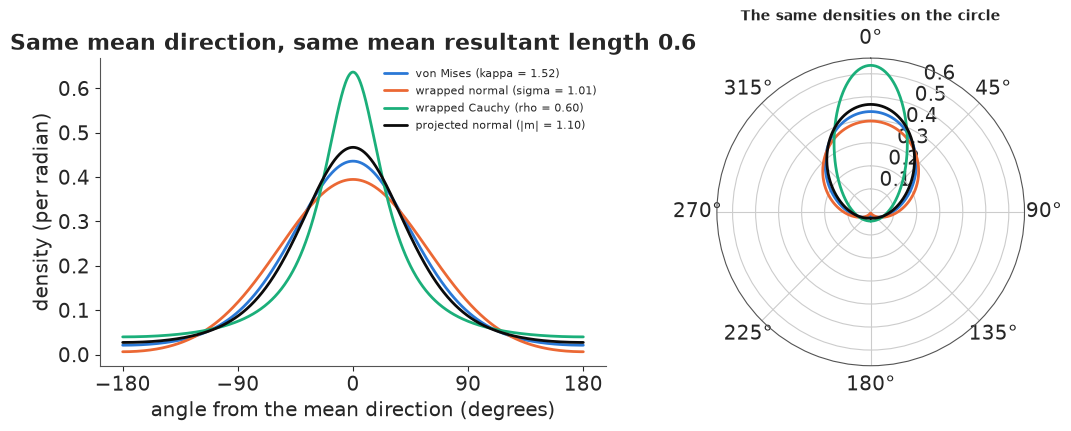

In [3]:
R_target = 0.6
grid = np.linspace(-np.pi, np.pi, 721)
k_vm = A1inv(R_target)
sig_wn = np.sqrt(-2 * np.log(R_target))                     # wrapped normal: R = exp(-sigma^2 / 2)
dens = {
    f"von Mises (kappa = {k_vm:.2f})": np.exp(vm_logpdf(grid, k_vm, 0.0)),
    f"wrapped normal (sigma = {sig_wn:.2f})": sum(np.exp(-(grid + TWO_PI * j) ** 2 / (2 * sig_wn ** 2))
                                                 for j in range(-4, 5)) / np.sqrt(TWO_PI * sig_wn ** 2),
    "wrapped Cauchy (rho = 0.60)": (1 - R_target ** 2) / (TWO_PI * (1 + R_target ** 2 - 2 * R_target * np.cos(grid))),
}
# projected normal: find |m| giving R = 0.6 (R = E cos(theta) under the density)
dth = grid[1] - grid[0]
pn_R = lambda m: np.sum(np.cos(grid[:-1]) * np.exp(pn_logpdf(grid[:-1], m, 0.0))) * dth
m_pn = brentq(lambda m: pn_R(m) - R_target, 0.01, 10)
dens[f"projected normal (|m| = {m_pn:.2f})"] = np.exp(pn_logpdf(grid, m_pn, 0.0))

fig = plt.figure(figsize=(11, 4.2))
ax = fig.add_subplot(1, 2, 1)
axp = fig.add_subplot(1, 2, 2, projection="polar")
cols = [BLUE, ORANGE, AQUA, INK]
for (lab, d), c in zip(dens.items(), cols):
    print(f"{lab:36s} integrates to {np.sum(d[:-1]) * dth:.4f}; peak {d.max():.3f}; "
          f"density opposite the mean {d[0]:.3f}")
    ax.plot(np.rad2deg(grid), d, color=c, lw=2, label=lab)
    axp.plot(grid, d, color=c, lw=2)
ax.set(xlabel="angle from the mean direction (degrees)", ylabel="density (per radian)",
       xticks=[-180, -90, 0, 90, 180], title="Same mean direction, same mean resultant length 0.6")
ax.legend(fontsize=8)
axp.set_theta_zero_location("N")
axp.set_theta_direction(-1)
axp.set_title("The same densities on the circle", fontsize=10);

At equal $\bar R$ the von Mises and the wrapped normal are almost indistinguishable (at larger
$\kappa$ they converge; in practice the von Mises is used because its density has a closed form). The
wrapped Cauchy has a sharper peak *and* more mass far from the mean: it is the heavy-tailed option. The
projected normal is flatter at the top. Which shape suits a dataset is an empirical question that LOO
can answer - we will do that for the wind in Part D.

### What does nothing look like?

Before looking for patterns, a control. Oklahoma's magnitude 3+ earthquakes (2005-2019) were mostly
induced by wastewater injection, which runs day and night. Their times of day, in local time:

n = 2917; mean resultant length R = 0.0215; mean hour 13.8
expected R under uniformity, sqrt(pi / 4n) = 0.0164; Rayleigh statistic nR^2 = 1.35, p ~ exp(-nR^2) = 0.26


posterior kappa: median 0.051, 94% upper bound 0.089; implied R at the upper bound 0.044
elpd: uniform -5361.1, von Mises -5361.7 +- 1.7 (difference -0.6)


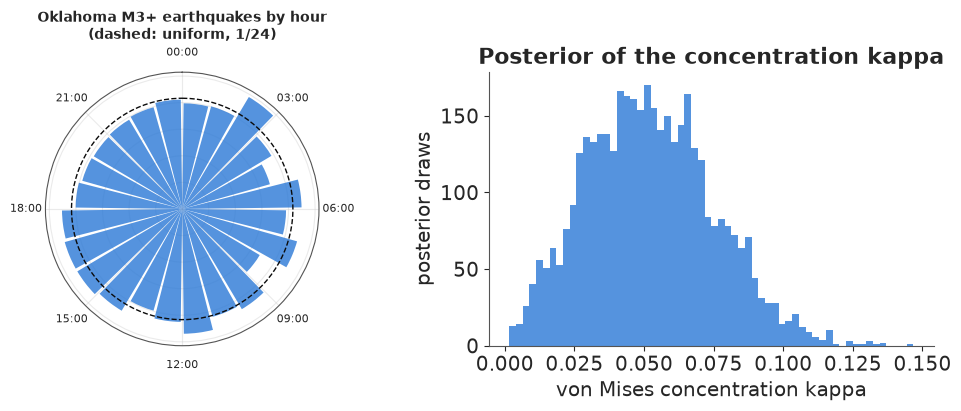

In [4]:
quakes = data.load("oklahoma_quakes")
t_local = pd.to_datetime(quakes.time, utc=True).dt.tz_convert("America/Chicago")
q_hour = (t_local.dt.hour + t_local.dt.minute / 60).to_numpy()
q_th = TWO_PI * q_hour / 24
n_q = len(q_th)
q_mean, q_R = mean_resultant(q_th)
Z = n_q * q_R ** 2
print(f"n = {n_q}; mean resultant length R = {q_R:.4f}; mean hour {np.rad2deg(q_mean) % 360 / 15:.1f}")
print(f"expected R under uniformity, sqrt(pi / 4n) = {np.sqrt(np.pi / (4 * n_q)):.4f}; "
      f"Rayleigh statistic nR^2 = {Z:.2f}, p ~ exp(-nR^2) = {np.exp(-Z):.2f}")

with pm.Model() as m_quake:
    eta = pm.Normal("eta", 0, 1, shape=2)                  # natural parameters of a von Mises
    kappa = pm.Deterministic("kappa", pt.sqrt(pt.sum(eta ** 2)))
    pm.Potential("ll", pt.sum(vm_lp(q_th, eta[0], eta[1])))
    idata_q = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
kq = idata_q.posterior["kappa"].values.ravel()
eq = az.extract(idata_q, var_names=["eta"]).values.T
ll_q = vm_logpdf(q_th[None, :], eq[::4, 0:1], eq[::4, 1:2])
loo_q = loo_from_ll(ll_q)
print(f"posterior kappa: median {np.median(kq):.3f}, 94% upper bound {np.quantile(kq, 0.94):.3f}; "
      f"implied R at the upper bound {A1(np.quantile(kq, 0.94)):.3f}")
print(f"elpd: uniform {-n_q * np.log(TWO_PI):.1f}, von Mises {loo_q.elpd:.1f} +- {loo_q.se:.1f} "
      f"(difference {loo_q.elpd + n_q * np.log(TWO_PI):.1f})")

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(1, 2, 1, projection="polar")
clockface(ax)
cnt, edges = np.histogram(q_th, bins=24, range=(0, TWO_PI))
ax.bar(edges[:-1] + np.pi / 24, cnt / n_q, width=TWO_PI / 24 * 0.9, color=BLUE, alpha=0.8)
ax.plot(np.linspace(0, TWO_PI, 200), np.full(200, 1 / 24), color=INK, lw=1, ls="--")
ax.set_yticklabels([])
ax.set_title("Oklahoma M3+ earthquakes by hour\n(dashed: uniform, 1/24)", fontsize=10)
ax = fig.add_subplot(1, 2, 2)
ax.hist(kq, bins=60, color=BLUE, alpha=0.8)
ax.set(xlabel="von Mises concentration kappa", ylabel="posterior draws",
       title="Posterior of the concentration kappa");

The histogram by hour looks bumpy, but each bar holds only about 120 quakes, so bumps of ±10% are
noise. The mean resultant length of 0.02 is close to what 2,917 uniformly scattered times give on
average (0.016): $\bar R$ is **biased upwards** and never exactly 0 in a finite sample, so it cannot be read
on its own. The Rayleigh test does not reject uniformity.

The Bayesian version fits a von Mises and asks how concentrated it is. The posterior of $\kappa$ sits
close to 0 (median 0.05; $\kappa$ is the length of a 2-D vector here, so like any length its posterior
thins out towards exactly 0). Even its 94% upper bound, 0.09, implies a mean resultant length of
about 0.04 - a daily cycle too weak to matter. LOO says the same in its own currency: the extra
flexibility buys nothing (the uniform is 0.6 nats better, with a standard error of 1.7). Note the parameterisation: we sampled the natural
parameters $\eta = \kappa(\cos\mu, \sin\mu)$, not $(\mu, \kappa)$. When $\kappa \approx 0$ the mean direction $\mu$ is
meaningless and would wander over the whole circle; in $\eta$ the posterior is a harmless blob around
the origin. That idea returns throughout.

## B. The wind at Santa Barbara

Three details of the data matter before any model:

* **Calms.** When the wind speed is 0 the direction is *undefined*, and the report says 0 degrees.
  Treating 27% of the hours as north winds would invent a strong northerly mode. There are also no
  speeds of 1 or 2 knots in the file: the lightest winds are reported as calm. We drop calms and model
  the direction *given* a wind of at least 3 knots.
* **Rounding.** ASOS reports the direction in steps of 10 degrees. With the concentrations we will
  see ($\kappa \le 5$, an angular spread of 25 degrees or more) a 10-degree bin barely matters for the
  likelihood, but it matters for residual checks, where we will jitter within the bin.
* **Which clock?** The sea breeze follows the sun, not the clock. Daylight-saving time shifts the
  clock by an hour for eight months of the year, which would smear every hour-of-day effect. We use
  Pacific **standard** time (UTC - 8) all year. At Santa Barbara solar noon is then close to 12:00
  (within about 20 minutes over the year).

We fit on 2021-2022 and keep **2023** aside to check predictions on data the models never saw.

training reports (2021-2022, not calm): 12,023; held-out 2023: 6,026
directions are multiples of 10 degrees: True


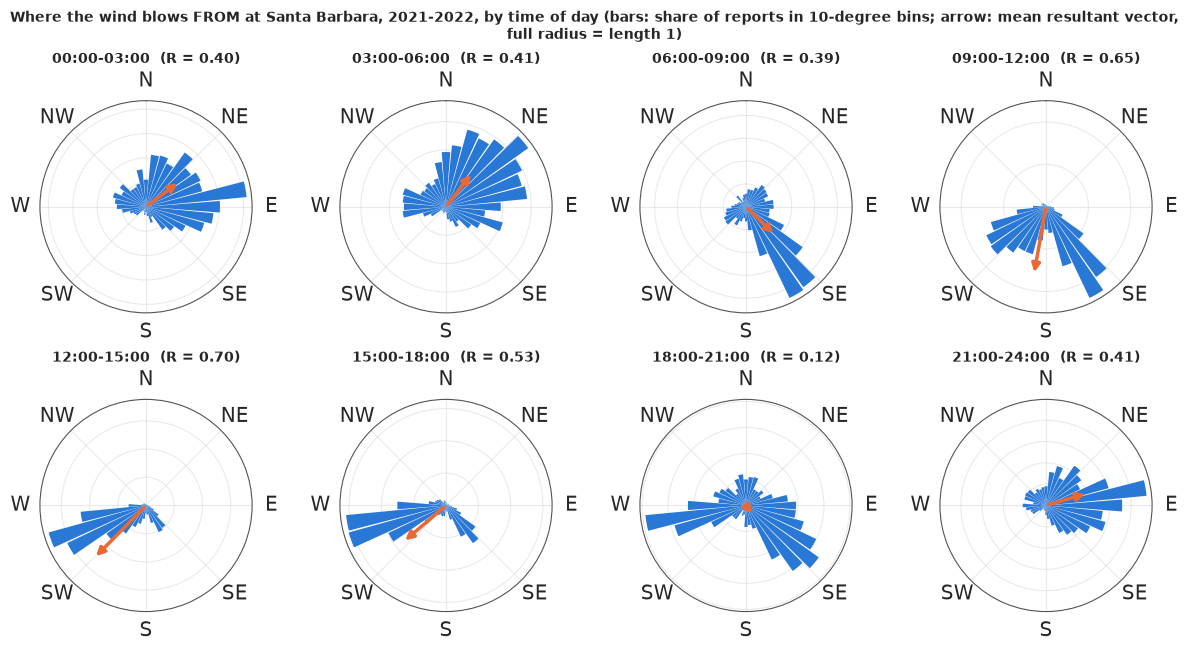

In [5]:
wind["hour"] = wind.lst.dt.hour + wind.lst.dt.minute / 60
wind["doy"] = (wind.lst.dt.dayofyear - 1 + wind.hour / 24) / 365.25        # fraction of the year
wind["year"] = wind.lst.dt.year
train = wind[wind.year < 2023].reset_index(drop=True)
test = wind[wind.year == 2023].reset_index(drop=True)
th = train.theta.to_numpy()
n_tr = len(th)
print(f"training reports (2021-2022, not calm): {n_tr:,}; held-out 2023: {len(test):,}")
print("directions are multiples of 10 degrees:", bool(np.all(train.drct % 10 == 0)))

blocks = [(h, h + 3) for h in range(0, 24, 3)]
fig, axes = plt.subplots(2, 4, figsize=(12, 6.4), subplot_kw={"projection": "polar"})
for ax, (h0, h1) in zip(axes.ravel(), blocks):
    sel = (train.hour >= h0) & (train.hour < h1)
    t = np.deg2rad(train.drct[sel])
    cnt, edges = np.histogram(np.mod(t, TWO_PI), bins=36, range=(-np.pi / 36, TWO_PI - np.pi / 36))
    ax.bar(edges[:-1] + np.pi / 36, cnt / sel.sum(), width=TWO_PI / 36 * 0.9, color=BLUE)
    mu_b, R_b = mean_resultant(t)
    compass(ax, labels=True)
    rmax = ax.get_ylim()[1]
    ax.annotate("", xy=(mu_b, R_b * rmax), xytext=(0, 0), zorder=5,
                arrowprops=dict(arrowstyle="-|>", color=ORANGE, lw=2.5))
    ax.set_yticklabels([])
    ax.set_title(f"{h0:02d}:00-{h1:02d}:00  (R = {R_b:.2f})", fontsize=10)
fig.suptitle("Where the wind blows FROM at Santa Barbara, 2021-2022, by time of day (bars: share of reports in "
             "10-degree bins; arrow: mean resultant vector,\nfull radius = length 1)", fontsize=10);

A rose diagram is a histogram wrapped round a compass. Read the eight clocks in order:

* **night (21:00-06:00)**: a broad spread of winds from the east and northeast - air draining off the
  mountains and along the coast - with a small group from the west;
* **morning (06:00-12:00)**: first the south-southeast, then *two* groups at once, south-southeast and
  west-southwest, as the sea breeze sets in;
* **afternoon (12:00-18:00)**: the sea breeze from the west-southwest (240-270 degrees), by far the most
  concentrated wind of the day ($\bar R$ = 0.70);
* **evening (18:00-21:00)**: again two groups, the dying sea breeze from the west and a group from the
  southeast. The mean resultant vector points between them and is short ($\bar R$ = 0.12): in this
  block it describes neither.

A model with one mean direction per hour can follow the daily swing; the evening block already
suggests it will need more than one direction at a time.

## C. Does the direction depend on wind speed? Link functions on the circle

Strong winds here are westerlies; the lightest winds come from the northeast. Regressing a circular
response on a linear covariate $x$ (here the standardised log wind speed) needs a **link function** that
maps the real line into angles. The classic choice (Fisher & Lee 1992) is the **tan-half link**

$$\mu(x) = \mu_0 + 2\arctan(\beta x),$$

which moves the mean direction smoothly from $\mu_0 - \pi$ to $\mu_0 + \pi$ as $x$ runs over the line, with
$\theta \sim \text{VM}(\mu(x), \kappa)$. It has two traps, and it is worth seeing both before the fix.

### Trap 1: the likelihood has a second mode where the link becomes a step

For fixed $\beta$ the best $\mu_0$ and $\kappa$ have closed forms (the mean direction and the inverted
$A_1(\kappa) = \bar R$ of the angles $\theta_i - 2\arctan(\beta x_i)$), so the profile log-likelihood of $\beta$ costs
nothing to compute.

best: beta = 0.63, mu0 = 165 deg, kappa = 0.76, log-lik -20523
second mode: beta = -48, mu0 = 4 deg, kappa = 0.46, log-lik -21493
the valley between them: beta = -0.95, log-lik -22083


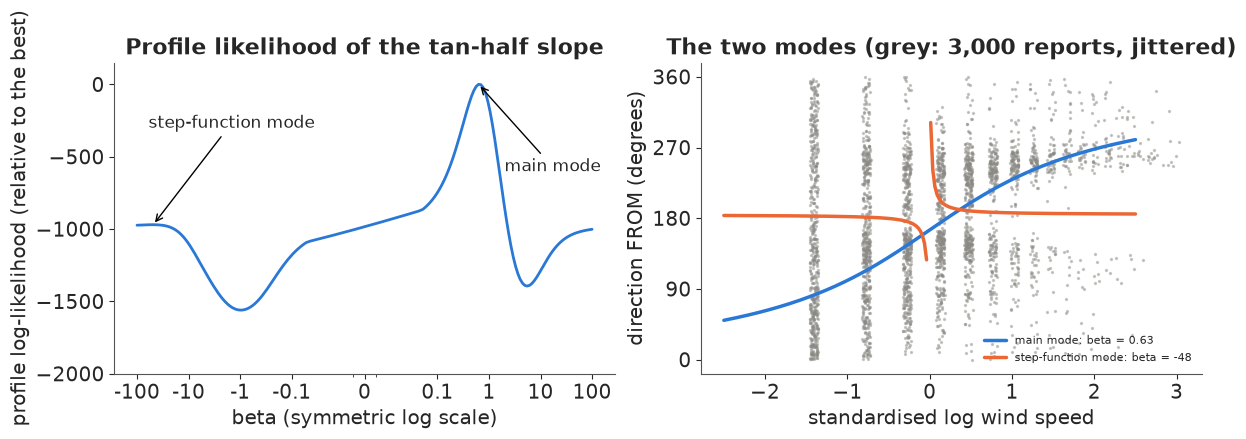

In [6]:
x_sp = np.log(train.sknt.to_numpy())
X_MEAN, X_SD = x_sp.mean(), x_sp.std()
x_sp = (x_sp - X_MEAN) / X_SD


def tanhalf_profile(beta, th=th, x=x_sp):
    mu0, R = mean_resultant(th - 2 * np.arctan(beta * x))
    k = A1inv(R)
    return len(th) * (k * R - np.log(TWO_PI) - np.log(special.i0e(k)) - k), mu0, k


betas = np.r_[-np.logspace(2, -2, 90), 0.0, np.logspace(-2, 2, 90)]
prof = np.array([tanhalf_profile(b) for b in betas])
i_best = np.argmax(prof[:, 0])
neg = betas < -0.2
i_step = np.flatnonzero(neg)[np.argmax(prof[neg, 0])]
print(f"best: beta = {betas[i_best]:.2f}, mu0 = {np.rad2deg(prof[i_best, 1]) % 360:.0f} deg, "
      f"kappa = {prof[i_best, 2]:.2f}, log-lik {prof[i_best, 0]:.0f}")
print(f"second mode: beta = {betas[i_step]:.0f}, mu0 = {np.rad2deg(prof[i_step, 1]) % 360:.0f} deg, "
      f"kappa = {prof[i_step, 2]:.2f}, log-lik {prof[i_step, 0]:.0f}")
i_valley = np.flatnonzero((betas < 0) & (betas > betas[i_step]))[np.argmin(prof[(betas < 0) & (betas > betas[i_step]), 0])]
print(f"the valley between them: beta = {betas[i_valley]:.2f}, log-lik {prof[i_valley, 0]:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(betas, prof[:, 0] - prof[i_best, 0], color=BLUE, lw=2)
axes[0].set_xscale("symlog", linthresh=0.05)
axes[0].set_xticks([-100, -10, -1, -0.1, 0, 0.1, 1, 10, 100])
axes[0].set_xticklabels(["-100", "-10", "-1", "-0.1", "0", "0.1", "1", "10", "100"])
axes[0].set(xlabel="beta (symmetric log scale)", ylabel="profile log-likelihood (relative to the best)",
            title="Profile likelihood of the tan-half slope", ylim=(-2000, 150))
axes[0].annotate("main mode", (betas[i_best], 0), xytext=(2, -600), arrowprops=dict(arrowstyle="->"))
axes[0].annotate("step-function mode", (betas[i_step], prof[i_step, 0] - prof[i_best, 0]),
                 xytext=(-60, -300), arrowprops=dict(arrowstyle="->"))
xs = np.linspace(-2.5, 2.5, 200)
sub = rng.choice(n_tr, 3000, replace=False)
axes[1].scatter(x_sp[sub] + rng.uniform(-0.05, 0.05, 3000), np.mod(train.drct.to_numpy()[sub] + rng.uniform(-5, 5, 3000), 360),
                s=2, color=MUTED, alpha=0.4)
for i, c, lab in ((i_best, BLUE, "main mode"), (i_step, ORANGE, "step-function mode")):
    mu = np.rad2deg(prof[i, 1] + 2 * np.arctan(betas[i] * xs)) % 360
    mu[np.abs(np.diff(mu, append=mu[-1])) > 180] = np.nan
    axes[1].plot(xs, mu, color=c, lw=2.5, label=f"{lab}: beta = {betas[i]:.2g}")
axes[1].set(xlabel="standardised log wind speed", ylabel="direction FROM (degrees)", yticks=range(0, 361, 90),
            title="The two modes (grey: 3,000 reports, jittered)")
axes[1].legend(fontsize=8, loc="lower right");

The main mode ($\beta \approx 0.6$) turns the mean direction from the northeast for light winds through
the south to the west for strong winds. But the profile does not fall away as $|\beta|$ grows: for large
negative $\beta$ it climbs again to a plateau (and, less high, for large positive $\beta$). There
$2\arctan(\beta x)$ is a **step** of $\pm\pi$ at $x = 0$: the
model says "light winds come from one direction and strong winds from exactly the opposite one", which
is a crude but not absurd description of these data. It is about 970 log-likelihood units worse
than the main mode, and separated from it by a valley 1,560 units below the main mode. (Speeds are
whole knots, so the log speeds form the vertical stripes in the right panel.) A sampler that starts
on the wrong side of the valley will stay there.

### Trap 2: a wrapped prior on the intercept

The obvious prior for an angle is $\mu_0 \sim \text{Uniform}(-\pi, \pi)$. PyMC maps an interval to the real line
with a logit transform, so $-\pi$ and $\pi$ become $-\infty$ and $+\infty$: two points that are the *same
direction* are infinitely far apart for the sampler. Here the best $\mu_0$ is about 165 degrees (2.9
radians), close to that seam. We fit this "obvious" model with nutpie's default settings.

In [7]:
with pm.Model() as m_tanhalf_uniform:
    mu0 = pm.Uniform("mu0", -np.pi, np.pi)
    beta = pm.Normal("beta", 0, 2)
    kappa = pm.Gamma("kappa", 2.0, 1.0)
    pm.VonMises("y", mu=mu0 + 2 * pt.arctan(beta * x_sp), kappa=kappa, observed=th)
    idata_th_u = pm.sample(random_seed=RANDOM_SEED, progressbar=False)


def per_chain(idata, names, deg=()):
    out = {}
    for v in names:
        a = idata.posterior[v].values
        out[v] = (np.rad2deg(mean_resultant(a, axis=1)[0]) % 360) if v in deg else a.mean(1)
    out["mean logp"] = idata.sample_stats["logp"].values.mean(1)
    out["divergences"] = idata.sample_stats["diverging"].values.sum(1)
    return pd.DataFrame(out, index=[f"chain {c}" for c in range(len(out["mean logp"]))])


print(az.summary(idata_th_u, var_names=["mu0", "beta", "kappa"], round_to=3).to_string())
print(per_chain(idata_th_u, ["mu0", "beta", "kappa"], deg=("mu0",)).round(2).to_string())

        mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  mcse_sd
mu0   -0.076  2.126    -3.141     2.884     4.900    10.978  2.411      1.059    0.530
beta  -9.185  9.825   -20.224     0.668     5.250    10.815  2.099      4.882    0.011
kappa  0.597  0.152     0.429     0.774     5.444    11.623  1.983      0.076    0.005
            mu0   beta  kappa  mean logp  divergences
chain 0  359.07 -18.96   0.45  -21574.92            0
chain 1  180.08   0.57   0.73  -20638.85            0
chain 2  164.41   0.66   0.76  -20529.04            0
chain 3  359.09 -19.01   0.45  -21574.83            0


Everything a careless check looks at is fine: **zero divergences**, no warnings about step size. But
$\hat R$ is about 2, and the per-chain means show why - the four chains found three different answers:

* two chains sit at a very large negative $\beta$: the **step-function mode** of trap 1;
* one chain found the main mode ($\beta \approx 0.6$, $\mu_0 \approx 165$ degrees);
* one chain has $\mu_0$ pressed against $-\pi$: it wants to reach 165 degrees by going the short way round
  through 180, and the wall of the uniform prior does not let it. Its $\beta$ matches the main mode; its
  mean log density is lower than that chain's.

Only the per-chain view (and $\hat R$) reveals this; divergences never will. The wall is the known cure's
target: sample the direction as a **point in the plane** and take its angle. We give the intercept its
natural parameters $\eta_0 = \kappa(\cos\mu_0, \sin\mu_0)$ with a normal prior, so $\kappa = |\eta_0|$ and
$\mu_0 = \operatorname{atan2}(\eta_{0,2}, \eta_{0,1})$ - an unconstrained plane with no seam. (Sampling a free
point $(c, s)$ and using only its angle also works, but its length is then set only by the prior, and the
sampler funnels near the origin; tying the length to $\kappa$ lets the data identify it.)

In [8]:
with pm.Model() as m_tanhalf_plane:
    eta0 = pm.Normal("eta0", 0, 2, shape=2)
    mu0 = pm.Deterministic("mu0", pt.arctan2(eta0[1], eta0[0]))
    kappa = pm.Deterministic("kappa", pt.sqrt(pt.sum(eta0 ** 2)))
    beta = pm.Normal("beta", 0, 2)
    pm.VonMises("y", mu=mu0 + 2 * pt.arctan(beta * x_sp), kappa=kappa, observed=th)
    idata_th_p = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(per_chain(idata_th_p, ["mu0", "beta", "kappa"], deg=("mu0",)).round(2).to_string())

            mu0   beta  kappa  mean logp  divergences
chain 0  164.40   0.66   0.76  -20527.95            0
chain 1  358.99 -19.00   0.44  -21574.72            0
chain 2  164.47   0.66   0.76  -20527.88            0
chain 3  164.41   0.65   0.76  -20527.73            0


No chain is stuck at a wall any more - but the step-function mode is still there, because it is a
property of the *likelihood*, not of the parameterisation of $\mu_0$. With this seed, chains land in it
again. One could start every chain in the main mode (and we do below, to compare), but that hides the
problem rather than removing it.

### The fix: the canonical link

Section A noted that the von Mises is an exponential family in $\eta = \kappa(\cos\mu, \sin\mu)$:

$$\log p(\theta \mid \eta) = \eta_1\cos\theta + \eta_2\sin\theta - \log\{2\pi I_0(|\eta|)\}.$$

The log normaliser is convex in $\eta$, so the log-likelihood is **concave** in $\eta$. If $\eta$ is a *linear*
function of the coefficients - $\eta(x) = a + b\,x + c\,x^2$ with vectors $a, b, c \in \mathbb R^2$ - and the
priors are normal, the log posterior is concave in the coefficients: **one mode, no walls, no
wrapping**. The mean direction $\operatorname{atan2}(\eta_2, \eta_1)$ and the concentration $|\eta|$ both follow from
the linear predictor. This is the circular counterpart of the canonical link of a GLM (the logit for
a Bernoulli), and it is the model we use from here on. Its price is that direction and concentration
are tied to one predictor: near the origin of the $\eta$ plane the direction swings fast *and* the
concentration is low - which is also what real transitions look like.

In [9]:
with pm.Model() as m_canon_speed:
    coef = pm.Normal("coef", 0, 2, shape=(3, 2))          # rows: 1, x, x^2; columns: eta_1, eta_2
    eta = coef[0] + coef[1] * x_sp[:, None] + coef[2] * (x_sp ** 2)[:, None]
    pm.Potential("ll", pt.sum(vm_lp(th, eta[:, 0], eta[:, 1])))
    idata_canon = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(az.summary(idata_canon, var_names=["coef"], round_to=3).to_string())
print(per_chain(idata_canon, []).round(1).to_string())

# for a fair comparison: the tan-half model with every chain started in its main mode, no start jitter
b0, m0, k0 = betas[i_best], prof[i_best, 1], prof[i_best, 2]
with m_tanhalf_plane:
    idata_th_main = pm.sample(random_seed=RANDOM_SEED, progressbar=False,
                              initvals={"eta0": np.array([k0 * np.cos(m0), k0 * np.sin(m0)]), "beta": b0},
                              compile_kwargs={"jitter_rvs": set()})
print(per_chain(idata_th_main, ["mu0", "beta", "kappa"], deg=("mu0",)).round(3).to_string())

             mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  mcse_sd
coef[0, 0] -0.827  0.019    -0.858    -0.796  2647.591  2747.916  1.000        0.0      0.0
coef[0, 1]  0.107  0.018     0.078     0.137  3087.182  2749.710  1.001        0.0      0.0
coef[1, 0] -0.259  0.015    -0.283    -0.236  3588.011  2821.647  1.001        0.0      0.0
coef[1, 1] -0.462  0.015    -0.486    -0.438  3891.339  3186.816  1.001        0.0      0.0
coef[2, 0]  0.359  0.013     0.338     0.380  2599.791  2732.504  1.000        0.0      0.0
coef[2, 1] -0.222  0.014    -0.245    -0.199  2924.624  2715.726  1.001        0.0      0.0
         mean logp  divergences
chain 0   -20289.0            0
chain 1   -20289.1            0
chain 2   -20288.9            0
chain 3   -20289.0            0


             mu0   beta  kappa  mean logp  divergences
chain 0  164.485  0.654  0.763 -20527.841            0
chain 1  164.500  0.654  0.762 -20527.812            0
chain 2  164.453  0.655  0.763 -20527.874            0
chain 3  164.469  0.654  0.762 -20527.782            0


In [10]:
cd = az.extract(idata_canon, var_names=["coef"], num_samples=1000, random_seed=1).transpose("sample", ...).values
tm = az.extract(idata_th_main, var_names=["mu0", "beta", "kappa"], num_samples=1000, random_seed=1)
mu0_d, beta_d, kap_d = (tm[v].values for v in ("mu0", "beta", "kappa"))


def canon_eta(c, x):
    return c[:, None, 0, :] + c[:, None, 1, :] * x[None, :, None] + c[:, None, 2, :] * (x ** 2)[None, :, None]


e = canon_eta(cd, x_sp)
ll_canon = vm_logpdf(th[None], e[..., 0], e[..., 1])
ll_th = kap_d[:, None] * np.cos(th[None] - mu0_d[:, None] - 2 * np.arctan(beta_d[:, None] * x_sp[None])) \
    - np.log(TWO_PI) - (np.log(special.i0e(kap_d)) + kap_d)[:, None]
loo_speed = {"canonical (quadratic)": loo_from_ll(ll_canon), "tan-half (main mode)": loo_from_ll(ll_th)}
del e, ll_canon, ll_th
print(az.compare(loo_speed, round_to=1).to_string())

                       rank  elpd_diff   dse  p_worse diag_diff diag_elpd    p     elpd    se  weight
canonical (quadratic)     0        0.0   0.0      NaN                      6.7 -20282.6  57.4     0.8
tan-half (main mode)      1     -241.9  29.9      1.0                      3.2 -20524.5  53.6     0.2


The canonical model samples cleanly with default settings - all four chains agree, no divergences,
no special starting values - and it fits better than the tan-half link even when that link is started
in its best mode. The following picture shows *why* it fits better. On the left, direction against
speed with 94% bands for the mean direction. On the right, a **polar spaghetti** plot: each thin curve
is one posterior draw of the mean resultant vector $(\text{direction}, \bar R)$ as speed increases from
3 to 25 knots (plotted as the point at angle = direction, radius = $A_1(\kappa)$); dots are the observed
mean resultant vectors in speed bins.

                         0        1        2        3        4        5       6       7       8
median speed (kn)     3.00     4.00     5.00     6.00     7.00     9.00   12.00   15.00   19.00
reports            2154.00  1899.00  1776.00  1647.00  2303.00  1113.00  700.00  329.00  102.00
mean direction       50.87   130.77   151.21   174.67   199.15   237.66  265.71  282.74  274.07
R                     0.16     0.23     0.35     0.45     0.46     0.47    0.49    0.56    0.78


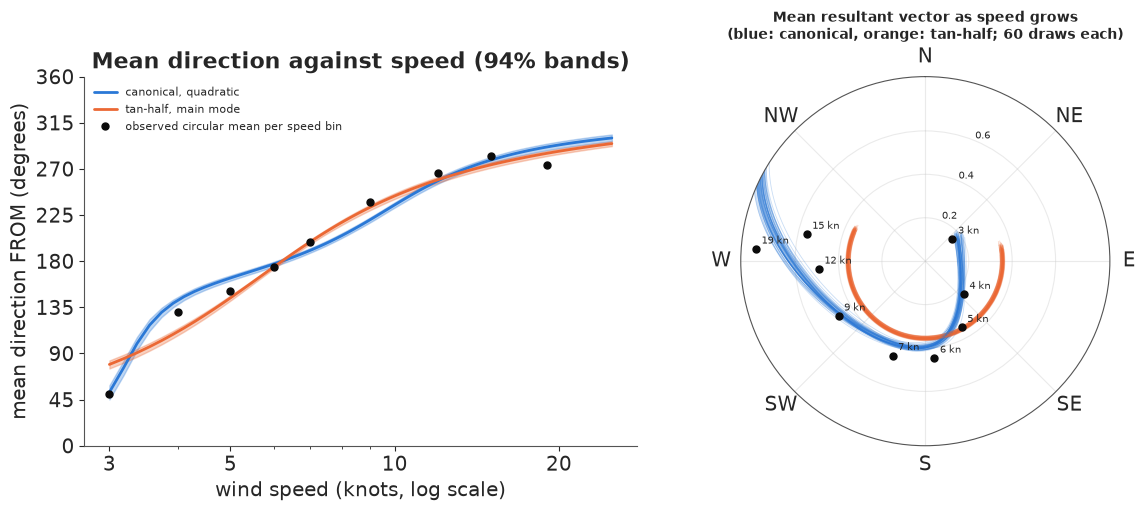

In [11]:
edges_kn = np.array([0, 3, 4, 5, 6, 8, 10, 13, 17, 60])     # the lightest reported wind is 3 knots
kn = np.zeros(len(edges_kn) - 1)
speeds = np.linspace(3, 25, 120)
xs_kn = (np.log(speeds) - X_MEAN) / X_SD
e_grid = canon_eta(cd[:300], xs_kn)
mu_c = np.arctan2(e_grid[..., 1], e_grid[..., 0])
R_c = A1(np.hypot(e_grid[..., 0], e_grid[..., 1]))
mu_t = mu0_d[:300, None] + 2 * np.arctan(beta_d[:300, None] * xs_kn[None])
R_t = np.broadcast_to(A1(kap_d[:300, None]), mu_t.shape)
bin_id = np.digitize(train.sknt.to_numpy(), edges_kn[1:-1], right=True)
ob_mu, ob_R = np.array([mean_resultant(th[bin_id == j]) for j in range(len(kn))]).T
kn = np.array([np.median(train.sknt.to_numpy()[bin_id == j]) for j in range(len(kn))])
print(pd.DataFrame({"median speed (kn)": kn, "reports": np.bincount(bin_id),
                    "mean direction": np.rad2deg(ob_mu) % 360, "R": ob_R}).round(2).T.to_string())

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
for mu_s, c, lab in ((mu_c, BLUE, "canonical, quadratic"), (mu_t, ORANGE, "tan-half, main mode")):
    cm = mean_resultant(mu_s, axis=0)[0]
    dev = wrap(mu_s - cm)
    lo, hi = np.quantile(dev, [0.03, 0.97], axis=0)
    centre = np.rad2deg(np.unwrap(cm)) % 360
    ax.fill_between(speeds, centre + np.rad2deg(lo), centre + np.rad2deg(hi), color=c, alpha=0.3)
    ax.plot(speeds, centre, color=c, lw=2, label=lab)
ax.errorbar(kn, np.rad2deg(ob_mu) % 360, fmt="o", color=INK, ms=5, label="observed circular mean per speed bin")
ax.set(xscale="log", xlabel="wind speed (knots, log scale)", ylabel="mean direction FROM (degrees)",
       yticks=range(0, 361, 45), title="Mean direction against speed (94% bands)")
ax.set_xticks([3, 5, 10, 20])
ax.set_xticklabels(["3", "5", "10", "20"])
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.legend(fontsize=8, loc="upper left")
axp = fig.add_subplot(1, 2, 2, projection="polar")
compass(axp)
for i in range(60):
    axp.plot(mu_c[i], R_c[i], color=BLUE, lw=0.6, alpha=0.25)
    axp.plot(mu_t[i], R_t[i], color=ORANGE, lw=0.6, alpha=0.25)
axp.plot(ob_mu, ob_R, "o", color=INK, ms=5)
for m_, r_, k_ in zip(ob_mu, ob_R, kn):
    axp.annotate(f"{k_:g} kn", (m_, r_), fontsize=7, xytext=(4, 4), textcoords="offset points")
axp.set_ylim(0, 0.85)
axp.set_yticks([0.2, 0.4, 0.6])
axp.tick_params(axis="y", labelsize=7)
axp.set_title("Mean resultant vector as speed grows\n(blue: canonical, orange: tan-half; 60 draws each)", fontsize=10);

The observed mean resultant vectors (dots) trace a path that starts near the centre for the lightest
winds (3 knots: from the northeast, but barely concentrated, $\bar R = 0.16$), swings through the
southeast and south with $\bar R$ growing from 0.23 to 0.46, and ends in the west for the strongest winds
($\bar R$ 0.5-0.8). The tan-half link can only move the
direction at a **constant concentration** - its spaghetti is an arc of a circle - so it overstates how
concentrated light winds are and understates it for moderate ones. The canonical link moves the point
freely in the plane and follows the path. Both sets of curves are tight: with 12,000 reports the
uncertainty in the *mean* is small; the spread of individual winds around it (the grey cloud above) is
large.

Two honest caveats. The reports are hourly and strongly autocorrelated, so LOO over hours treats
12,000 reports as more independent information than they are; Part D uses a held-out year as the
stricter test. And speed and direction are both outcomes of the same weather: this is a description of
the direction *given* the speed, not a causal effect of speed.

## D. Direction on hour of day and season: circular predictors

The daily swing is the dominant signal. Hour of day and day of year are themselves circular
**predictors**, and a circular predictor is the easy case: represent it by its harmonics
$\cos(k\cdot 2\pi h/24), \sin(k\cdot 2\pi h/24)$, which are continuous across midnight and New Year. We use three
daily harmonics, two annual harmonics and the products of the first two daily with the first annual
harmonic (so the daily cycle can change with the season): 19 features including the intercept.

Three models for the direction, each with the features entering linearly (so each has $19 \times 2$
coefficients):

1. **von Mises, canonical link**: $\eta(h, d) = F(h, d)\,B$, as in Part C.
2. **projected normal**: a latent vector $z \sim N(F(h, d)\,B, I)$ whose angle is the direction. The mean
   vector can wander anywhere in the plane, including the origin, so there is no wrapping at all; the
   density has a closed form once the latent length is integrated out,
   $p(\theta) = \frac{1}{2\pi} e^{-|m|^2/2}\{1 + u\,\Phi(u)/\phi(u)\}$ with $u = m\cdot(\cos\theta, \sin\theta)$.
3. **a mixture of two regimes**: an easterly regime (night drainage and morning flow) and a westerly
   regime (the sea breeze), each a von Mises whose natural parameters follow a smaller set of features
   (intercept, two daily and one annual harmonic), with the probability of the westerly regime following
   all 19 features through a logistic link.

Priors: normal(0, 2) on the intercepts and normal(0, 1) on the other coefficients. With harmonics in
$[-1, 1]$, a prior draw of $\eta$ has a length of a few units: the implied concentrations at the
training rows have a prior median of about 4 and a 90% range of about 1 to 8 - from "barely a
preferred direction" to "a narrow sea breeze".

In [12]:
def features(df):
    h = TWO_PI * df.hour.to_numpy() / 24
    d = TWO_PI * df.doy.to_numpy()
    cols, names = [np.ones_like(h)], ["1"]
    for k in (1, 2, 3):
        cols += [np.cos(k * h), np.sin(k * h)]
        names += [f"cos{k}h", f"sin{k}h"]
    for k in (1, 2):
        cols += [np.cos(k * d), np.sin(k * d)]
        names += [f"cos{k}d", f"sin{k}d"]
    for k in (1, 2):
        for a, an in ((np.cos(k * h), f"cos{k}h"), (np.sin(k * h), f"sin{k}h")):
            for b, bn in ((np.cos(d), "cos1d"), (np.sin(d), "sin1d")):
                cols.append(a * b)
                names.append(f"{an}*{bn}")
    return np.column_stack(cols), names


F_tr, FEAT = features(train)
F_te, _ = features(test)
SMALL = [0, 1, 2, 3, 4, 7, 8]                              # 1, cos1h, sin1h, cos2h, sin2h, cos1d, sin1d
prior_sd = np.r_[2.0, np.ones(len(FEAT) - 1)]
coords = {"feat": FEAT, "comp": ["eta1", "eta2"], "sfeat": [FEAT[i] for i in SMALL],
          "regime": ["easterly", "westerly"]}

# prior predictive: implied concentration at the training rows
B_prior = rng.normal(0, prior_sd[None, :, None], size=(200, len(FEAT), 2))
kap_prior = np.hypot(*np.moveaxis(np.einsum("nf,sfc->snc", F_tr[:2000], B_prior), -1, 0))
print("prior concentration at training rows: quantiles 5/50/95% =", np.round(np.quantile(kap_prior, [0.05, 0.5, 0.95]), 2))

t0 = time.time()
with pm.Model(coords=coords) as m_vm:
    B = pm.Normal("B", 0, prior_sd[:, None], dims=("feat", "comp"))
    eta = pt.dot(F_tr, B)
    pm.Potential("ll", pt.sum(vm_lp(th, eta[:, 0], eta[:, 1])))
    idata_vm = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(f"von Mises regression: {time.time() - t0:.0f} s")

t0 = time.time()
with pm.Model(coords=coords) as m_pn:
    B = pm.Normal("B", 0, prior_sd[:, None], dims=("feat", "comp"))
    m = pt.dot(F_tr, B)
    u = m[:, 0] * np.cos(th) + m[:, 1] * np.sin(th)
    pm.Potential("ll", pt.sum(-np.log(TWO_PI) - 0.5 * pt.sum(m ** 2, axis=1)
                              + pt.log1p(u * np.sqrt(np.pi / 2) * pt.erfcx(-u / np.sqrt(2)))))
    idata_pn = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(f"projected normal regression: {time.time() - t0:.0f} s")

MU_PRIOR = wrap(np.deg2rad([90.0, 250.0]))                 # easterly from E, westerly from WSW
t0 = time.time()
with pm.Model(coords=coords) as m_mix:
    B0 = pm.Normal("B0", 2.0 * np.column_stack([np.cos(MU_PRIOR), np.sin(MU_PRIOR)]), 1.0, dims=("regime", "comp"))
    Bh = pm.Normal("Bh", 0, 1, shape=(2, len(SMALL) - 1, 2))
    Bc = pt.concatenate([B0[:, None, :], Bh], axis=1)      # regime x small feature x component
    e_e = pt.dot(F_tr[:, SMALL], Bc[0])
    e_w = pt.dot(F_tr[:, SMALL], Bc[1])
    g = pm.Normal("g", 0, np.r_[1.5, np.ones(len(FEAT) - 1)], dims="feat")
    z = pt.dot(F_tr, g)
    ll = pt.logaddexp(-pm.math.log1pexp(z) + vm_lp(th, e_e[:, 0], e_e[:, 1]),
                      -pm.math.log1pexp(-z) + vm_lp(th, e_w[:, 0], e_w[:, 1]))
    pm.Potential("ll", pt.sum(ll))
    idata_mix = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(f"mixture of regimes: {time.time() - t0:.0f} s")

for name, idd, vs in (("von Mises", idata_vm, ["B"]), ("projected normal", idata_pn, ["B"]),
                      ("mixture", idata_mix, ["B0", "Bh", "g"])):
    s = pd.concat([az.summary(idd, var_names=[v], round_to=4) for v in vs])
    print(f"{name:17s} max r_hat {s.r_hat.max():.3f}, min bulk ESS {s.ess_bulk.min():.0f}, "
          f"divergences {int(idd.sample_stats['diverging'].sum())}, mean tree depth "
          f"{float(idd.sample_stats['depth'].mean()):.1f}, warm-up {idd.posterior.attrs.get('tuning_steps')}")
print(per_chain(idata_mix, []).round(1).to_string())
print("regime intercept directions per chain (deg):",
      np.round(np.rad2deg(np.arctan2(idata_mix.posterior["B0"].values[..., 1],
                                     idata_mix.posterior["B0"].values[..., 0]).mean(1)) % 360).tolist())

prior concentration at training rows: quantiles 5/50/95% = [1.03 3.96 8.23]


von Mises regression: 9 s


projected normal regression: 7 s


mixture of regimes: 68 s
von Mises         max r_hat 1.004, min bulk ESS 5664, divergences 0, mean tree depth 3.0, warm-up 400
projected normal  max r_hat 1.005, min bulk ESS 7265, divergences 0, mean tree depth 3.0, warm-up 400


mixture           max r_hat 1.006, min bulk ESS 733, divergences 0, mean tree depth 3.9, warm-up 400
         mean logp  divergences
chain 0   -15867.8            0
chain 1   -15867.4            0
chain 2   -15867.7            0
chain 3   -15867.4            0
regime intercept directions per chain (deg): [[127.0, 259.0], [127.0, 259.0], [127.0, 258.0], [127.0, 259.0]]


All three sample cleanly (the mixture takes longest). A mixture invites **label switching** - two
chains could call the sea breeze "regime 1" and "regime 2" - and here the regimes are anchored by
their priors on direction (east vs west-southwest), which is physically meaningful, and the chains
agree on the regimes' directions. That has to be checked, not assumed: Part E shows what happens
without such an anchor.

### Which model predicts better?

We score each model twice: PSIS-LOO on the 2021-2022 training reports, and the log predictive density
of every report of **2023**, which none of the models saw. Autocorrelated hours make the LOO standard
errors too small; for 2023 we compute the standard error of the difference from **daily** sums, so
that correlated hours within a day count as one unit.

In [13]:
S_LL = 1000
draws = {
    "vm": az.extract(idata_vm, var_names=["B"], num_samples=S_LL, random_seed=1).transpose("sample", ...).values,
    "pn": az.extract(idata_pn, var_names=["B"], num_samples=S_LL, random_seed=1).transpose("sample", ...).values,
}
mx = az.extract(idata_mix, var_names=["B0", "Bh", "g"], num_samples=S_LL, random_seed=1)
draws["mix"] = (np.concatenate([mx["B0"].transpose("sample", ...).values[:, :, None, :],
                                mx["Bh"].transpose("sample", ...).values], axis=2),
                mx["g"].transpose("sample", ...).values)


def loglik(model, F, th_obs):
    if model == "vm":
        e = np.einsum("nf,sfc->snc", F, draws["vm"])
        return vm_logpdf(th_obs[None], e[..., 0], e[..., 1])
    if model == "pn":
        m = np.einsum("nf,sfc->snc", F, draws["pn"])
        return pn_logpdf(th_obs[None], m[..., 0], m[..., 1])
    Bc, g = draws["mix"]
    ee = np.einsum("nf,srfc->srnc", F[:, SMALL], Bc)
    z = np.einsum("nf,sf->sn", F, g)
    return np.logaddexp(-np.logaddexp(0, z) + vm_logpdf(th_obs[None], ee[:, 0, :, 0], ee[:, 0, :, 1]),
                        -np.logaddexp(0, -z) + vm_logpdf(th_obs[None], ee[:, 1, :, 0], ee[:, 1, :, 1]))


const_mu, const_R = mean_resultant(th)
const_k = A1inv(const_R)
loos, lpd_test = {}, {}
th_te = test.theta.to_numpy()
for mname in ("vm", "pn", "mix"):
    loos[mname] = loo_from_ll(loglik(mname, F_tr, th))
    lt = loglik(mname, F_te, th_te)
    lpd_test[mname] = special.logsumexp(lt, axis=0) - np.log(S_LL)
    del lt
lpd_test["one direction"] = vm_logpdf(th_te, const_k * np.cos(const_mu), const_k * np.sin(const_mu))
lpd_test["uniform"] = np.full(len(th_te), -np.log(TWO_PI))
names_long = {"vm": "von Mises (canonical)", "pn": "projected normal", "mix": "mixture of 2 regimes"}
print(az.compare({names_long[k]: v for k, v in loos.items()}, round_to=1).to_string())

day = test.lst.dt.dayofyear.to_numpy()
rows = []
for k, v in lpd_test.items():
    dd = pd.Series(v - lpd_test["mix"]).groupby(day).sum()
    rows.append({"model": names_long.get(k, k), "2023 log score per report": v.mean(),
                 "total vs mixture": v.sum() - lpd_test["mix"].sum(),
                 "se (by day)": dd.std() * np.sqrt(len(dd))})
print(pd.DataFrame(rows).set_index("model").round(3).to_string())

                       rank  elpd_diff   dse  p_worse diag_diff diag_elpd     p     elpd    se  weight
mixture of 2 regimes      0        0.0   0.0      NaN                      58.4 -15822.0  97.0     0.9
von Mises (canonical)     1    -1563.3  62.9      1.0                      37.6 -17385.3  79.6     0.0
projected normal          2    -1581.9  65.7      1.0                      38.9 -17403.9  84.1     0.1
                       2023 log score per report  total vs mixture  se (by day)
model                                                                          
von Mises (canonical)                     -1.517          -916.131       74.947
projected normal                          -1.521          -939.988       80.661
mixture of 2 regimes                      -1.365             0.000        0.000
one direction                             -1.799         -2612.265      135.311
uniform                                   -1.838         -2848.531      148.217


Both scores agree on the ranking. In 2023, knowing the hour and season is worth 0.28 nats per report
(von Mises regression) to 0.43 nats (mixture) over a single mean direction for the whole year, which in
turn is only slightly better (0.04 nats) than knowing nothing. The von Mises and projected normal regressions are close
(the von Mises slightly ahead). The **mixture of regimes** is clearly best, in LOO and in 2023, by many
standard errors even with the day-level standard error. The rose diagrams in Part B suggested why; the
posterior predictive check shows it directly.

### Circular posterior predictive checks

For each 3-hour block, the bars are the observed rose diagram (30-degree bins); the lines and bands
are the median and 90% range of the same rose diagram in 200 replicated datasets from each model.

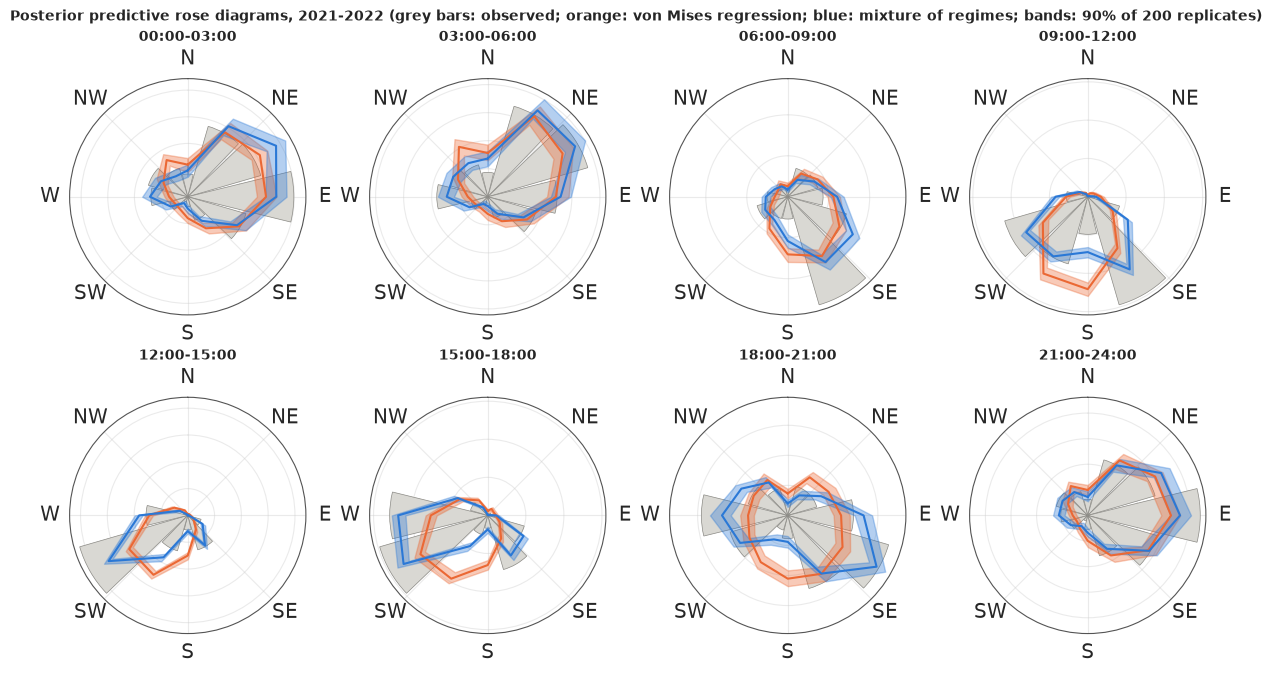

In [14]:
def simulate(mname, F, n_rep, seed=1):
    r = np.random.default_rng(seed)
    if mname == "vm":
        e = np.einsum("nf,sfc->snc", F, draws["vm"][:n_rep])
        return r.vonmises(np.arctan2(e[..., 1], e[..., 0]), np.hypot(e[..., 0], e[..., 1]))
    Bc, g = draws["mix"]
    ee = np.einsum("nf,srfc->srnc", F[:, SMALL], Bc[:n_rep])
    west = r.random((n_rep, len(F))) < special.expit(np.einsum("nf,sf->sn", F, g[:n_rep]))
    e1 = np.where(west, ee[:, 1, :, 0], ee[:, 0, :, 0])
    e2 = np.where(west, ee[:, 1, :, 1], ee[:, 0, :, 1])
    return r.vonmises(np.arctan2(e2, e1), np.hypot(e1, e2))


N_REP = 200
rep = {m_: simulate(m_, F_tr, N_REP) for m_ in ("vm", "mix")}
bins12 = np.linspace(-np.pi / 12, TWO_PI - np.pi / 12, 13)
blk = (train.hour.to_numpy() // 3).astype(int)
fig, axes = plt.subplots(2, 4, figsize=(12, 6.6), subplot_kw={"projection": "polar"})
centres = bins12[:-1] + np.pi / 12
for b, ax in enumerate(axes.ravel()):
    sel = blk == b
    obs = np.histogram(np.mod(th[sel], TWO_PI), bins=bins12)[0] / sel.sum()
    ax.bar(centres, obs, width=TWO_PI / 12 * 0.92, color=LIGHT, edgecolor=MUTED, lw=0.5)
    for m_, c in (("vm", ORANGE), ("mix", BLUE)):
        h = np.array([np.histogram(np.mod(rep[m_][i, sel], TWO_PI), bins=bins12)[0] for i in range(N_REP)]) / sel.sum()
        lo, md, hi = np.quantile(h, [0.05, 0.5, 0.95], axis=0)
        cc = np.r_[centres, centres[0]]
        ax.fill_between(cc, np.r_[lo, lo[0]], np.r_[hi, hi[0]], color=c, alpha=0.35)
        ax.plot(cc, np.r_[md, md[0]], color=c, lw=1.5)
    compass(ax)
    ax.set_yticklabels([])
    ax.set_title(f"{3 * b:02d}:00-{3 * b + 3:02d}:00", fontsize=10)
fig.suptitle("Posterior predictive rose diagrams, 2021-2022 (grey bars: observed; orange: von Mises regression; "
             "blue: mixture of regimes; bands: 90% of 200 replicates)", fontsize=10);

The single von Mises per hour and season cannot be in two places at once. In the 09:00-12:00 and
18:00-21:00 blocks, where the rose has two lobes, it puts much of its mass *between* them - in the
south, where the wind rarely blows - and it is too flat in the afternoon. The mixture puts its mass on
both lobes and is much closer everywhere. It is not perfect: the observed peaks are still sharper than
its bands in several blocks (the SSE morning wind, the SW afternoon sea breeze, the easterly at night).
Two regimes whose directions change smoothly with the hour are a simplification of real weather, and
with 12,000 reports the check has the power to show it.

A rose diagram checks one hour block at a time. The **probability integral transform** (PIT) checks every
report against its own predictive distribution: $u_i = P(\tilde\theta_i \text{ lies clockwise from the origin before } \theta_i)$,
estimated from the replicates. On a circle the PIT needs an **origin**; for a correct model $u$ is uniform
whatever the origin, but a misfit shows up differently from different origins, so we look at two. The
10-degree rounding would make the PIT lumpy, so each observed direction is jittered uniformly within
its bin first.

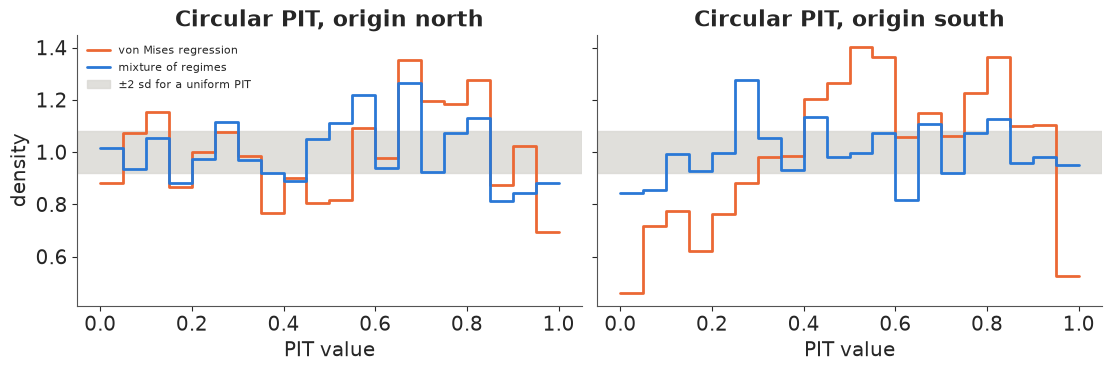

In [15]:
jit = th + np.deg2rad(rng.uniform(-5, 5, n_tr))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (org, olab) in zip(axes, ((0.0, "origin north"), (np.pi, "origin south"))):
    for m_, c, lab in (("vm", ORANGE, "von Mises regression"), ("mix", BLUE, "mixture of regimes")):
        u = (np.mod(rep[m_] - org, TWO_PI) < np.mod(jit - org, TWO_PI)[None]).mean(0)
        hist = np.histogram(u, bins=20, range=(0, 1))[0] / n_tr * 20
        ax.step(np.linspace(0, 1, 21), np.r_[hist, hist[-1]], where="post", color=c, lw=2, label=lab)
    band = 2 * np.sqrt(20 / n_tr)
    ax.axhspan(1 - band, 1 + band, color=LIGHT, alpha=0.8, label="±2 sd for a uniform PIT")
    ax.set(xlabel="PIT value", title=f"Circular PIT, {olab}")
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8);

A calibrated model gives a flat line at 1. The von Mises regression's PIT is far from flat, most
clearly from the southern origin (densities from 0.45 to 1.4). The mixture is much flatter from both
origins but still leaves the ±2 sd band in several bins - the same residual misfit as in the rose
diagrams. (The band assumes independent reports, which hourly winds are not, so it is too narrow.)

### What the mixture says about hours and seasons

The mixture's gate - the probability that the sea-breeze regime is blowing - is a smooth function of
hour and day of year. Its posterior mean and the width of its 94% interval:

P(westerly) posterior mean, 15:00 in mid-January / mid-July: 0.71 / 0.87


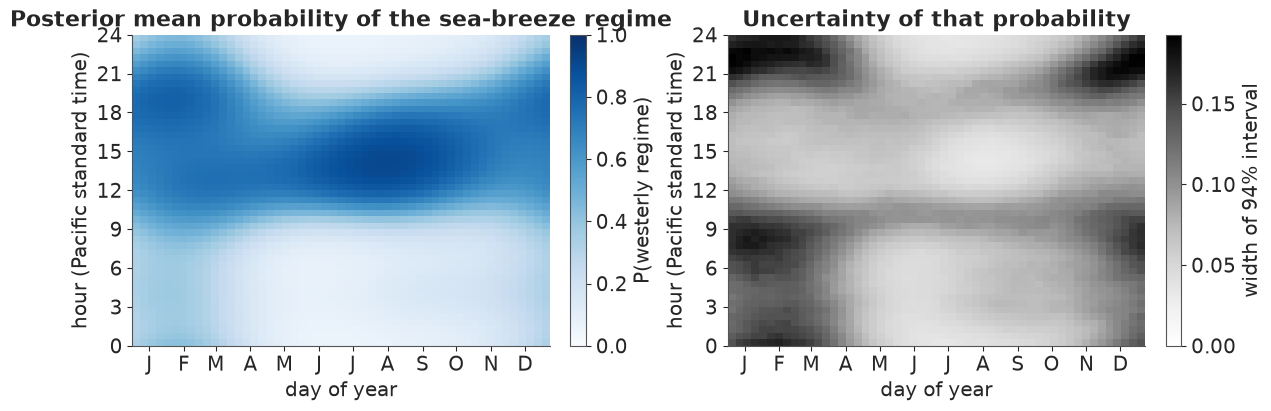

In [16]:
hh = np.arange(0, 24, 0.5) + 0.25
dd = np.arange(0, 365, 7) + 3.5
H, D = np.meshgrid(hh, dd, indexing="ij")
grid_df = pd.DataFrame({"hour": H.ravel(), "doy": D.ravel() / 365.25})
F_g, _ = features(grid_df)
Bc_d, g_d = draws["mix"]
p_west = special.expit(np.einsum("nf,sf->sn", F_g, g_d[:400])).reshape(400, *H.shape)
lo, hi = np.quantile(p_west, [0.03, 0.97], axis=0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].pcolormesh(dd, hh, p_west.mean(0), cmap="Blues", vmin=0, vmax=1, shading="auto")
fig.colorbar(im, ax=axes[0], label="P(westerly regime)")
im2 = axes[1].pcolormesh(dd, hh, hi - lo, cmap="Greys", vmin=0, shading="auto")
fig.colorbar(im2, ax=axes[1], label="width of 94% interval")
month_starts = np.cumsum([0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30])
for ax in axes:
    ax.set(xlabel="day of year", ylabel="hour (Pacific standard time)", yticks=range(0, 25, 3))
    ax.set_xticks(month_starts + 15)
    ax.set_xticklabels(list("JFMAMJJASOND"))
axes[0].set_title("Posterior mean probability of the sea-breeze regime")
axes[1].set_title("Uncertainty of that probability");
print("P(westerly) posterior mean, 15:00 in mid-January / mid-July: "
      f"{p_west.mean(0)[np.searchsorted(hh, 15), 2]:.2f} / {p_west.mean(0)[np.searchsorted(hh, 15), 28]:.2f}")

The westerly regime owns the early afternoon all year, most firmly in summer (close to 0.9 around
13:00-15:00 from June to September). In winter its peak is lower but it lasts later into the evening -
until about 21:00 - and keeps a probability of 0.2-0.4 even at night, when westerlies probably come
with passing weather systems rather than a sea breeze. The intervals are narrow in the afternoon and
widest (0.15-0.19) on winter evenings and early mornings, where the two regimes' directions overlap
and it is hard to tell which one a given wind belongs to.

### A clock of wind arrows

How to show a direction that depends on a time of day, with its uncertainty? Below, each panel is a
24-hour **clock**. At each hour, arrows show the predicted **mean resultant vector** of the wind,
drawn as the air moves (downwind, north up), with length proportional to $\bar R$: a long arrow means a
steady wind, a short one a wind that could come from anywhere. Each of the 40 thin arrows per hour is
one posterior draw, so the fan of arrows is the uncertainty in the mean vector.

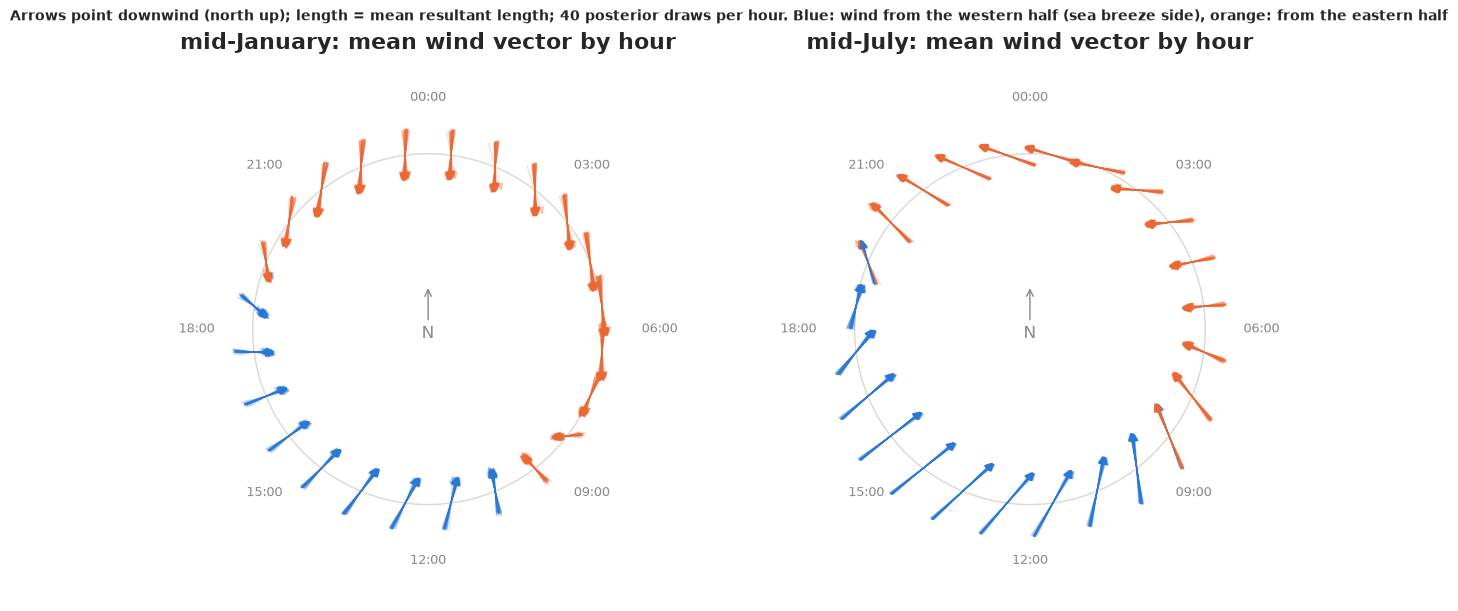

In [17]:
def mix_mean_vector(F, Bc, g):
    """Predictive E[exp(i theta)] of the mixture for each draw and row."""
    ee = np.einsum("nf,srfc->srnc", F[:, SMALL], Bc)
    p = special.expit(np.einsum("nf,sf->sn", F, g))
    z = 0
    for r_, w_ in ((0, 1 - p), (1, p)):
        k = np.hypot(ee[:, r_, :, 0], ee[:, r_, :, 1])
        z = z + w_ * A1(k) * np.exp(1j * np.arctan2(ee[:, r_, :, 1], ee[:, r_, :, 0]))
    return z


hours = np.arange(0, 24, 1.0) + 0.5
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, (doy, lab) in zip(axes, ((15, "mid-January"), (196, "mid-July"))):
    df_c = pd.DataFrame({"hour": hours, "doy": np.full(24, doy / 365.25)})
    Fc, _ = features(df_c)
    zc = mix_mean_vector(Fc, Bc_d[:40], g_d[:40])
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, color=LIGHT, lw=1))
    for j, h in enumerate(hours):
        ang = TWO_PI * h / 24
        cx, cy = np.sin(ang), np.cos(ang)
        for s_ in range(40):
            d_from = np.angle(zc[s_, j])
            L = 0.6 * np.abs(zc[s_, j])
            dx, dy = -L * np.sin(d_from), -L * np.cos(d_from)          # downwind, north up
            ax.add_patch(FancyArrowPatch((cx - dx / 2, cy - dy / 2), (cx + dx / 2, cy + dy / 2),
                                         arrowstyle="-|>", mutation_scale=11, lw=0.8,
                                         color=BLUE if np.cos(d_from - np.deg2rad(250)) > 0 else ORANGE,
                                         alpha=0.25))
    for h in range(0, 24, 3):
        a = TWO_PI * h / 24
        ax.text(1.32 * np.sin(a), 1.32 * np.cos(a), f"{h:02d}:00", ha="center", va="center", fontsize=9, color=MUTED)
    ax.annotate("N", (0, 0.25), xytext=(0, -0.05), ha="center", arrowprops=dict(arrowstyle="->", color=MUTED), color=MUTED)
    ax.set(xlim=(-1.55, 1.55), ylim=(-1.55, 1.55), aspect="equal", title=f"{lab}: mean wind vector by hour")
    ax.axis("off")
fig.suptitle("Arrows point downwind (north up); length = mean resultant length; 40 posterior draws per hour. "
             "Blue: wind from the western half (sea breeze side), orange: from the eastern half", fontsize=10);

In January the night and early-morning arrows point south - air from the north-northeast draining
out to sea - the late-morning arrows turn to point northwest (a southeasterly), and from about 11:00 to
19:00 the sea breeze pushes inland (arrows pointing northeast). In July the night flow comes from the
east (arrows pointing west), and the sea-breeze phase runs from about 10:00 to 19:00 with longer arrows:
a steadier wind. The shortest arrows are at the evening turnaround, not because the air is still (calms
are excluded) but because the direction is least predictable. The fans of 40 draws are narrow: the
mean vector is well determined, and the uncertainty that matters for a sailor is the spread of
individual winds, which the arrow length encodes.

### Circular intervals as arcs

For the direction of each *regime* at a given time, the natural uncertainty display is an arc on the
compass: the shortest arc holding 94% of the posterior draws (a circular HDI). Below: the westerly
regime at 15:00 and the easterly regime at 03:00, in mid-January and mid-July. Each arc sits at its
own radius; the tick is the posterior circular mean.

                      mean (deg)  94% arc from     to  width (deg)  kappa
regime / time                                                            
westerly, 15:00, Jan       255.2         253.3  257.2          3.9    4.0
westerly, 15:00, Jul       240.6         239.4  241.7          2.3    7.6
easterly, 03:00, Jan        29.4          25.7   33.3          7.5    3.2
easterly, 03:00, Jul        88.7          84.6   92.7          8.0    1.7


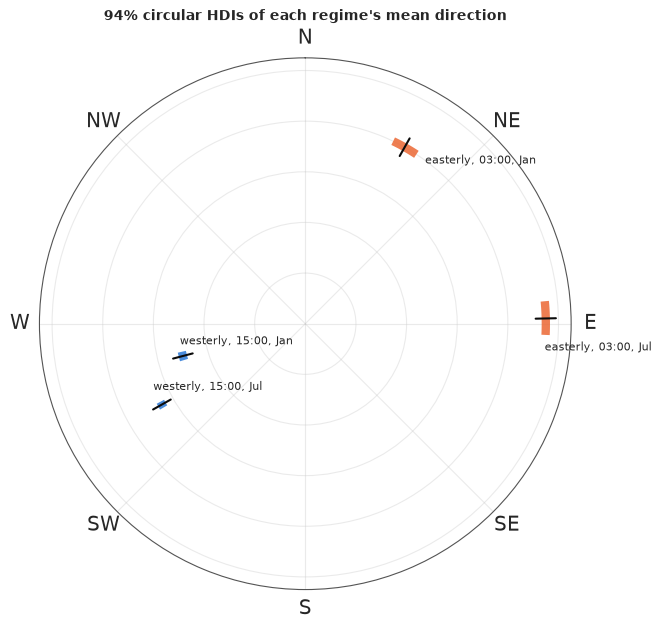

In [18]:
fig = plt.figure(figsize=(6.5, 6.5))
ax = fig.add_subplot(projection="polar")
compass(ax)
arcs = []
for rad, (hour, doy, reg, lab, c) in enumerate(
        ((15, 15, 1, "westerly, 15:00, Jan", BLUE), (15, 196, 1, "westerly, 15:00, Jul", BLUE),
         (3, 15, 0, "easterly, 03:00, Jan", ORANGE), (3, 196, 0, "easterly, 03:00, Jul", ORANGE)), start=1):
    Fp, _ = features(pd.DataFrame({"hour": [hour], "doy": [doy / 365.25]}))
    ee = np.einsum("nf,sfc->snc", Fp[:, SMALL], Bc_d[:, reg])[:, 0]
    mu_draw = np.arctan2(ee[:, 1], ee[:, 0])
    lo_, hi_, cm_ = circ_hdi(mu_draw)
    arcs.append({"regime / time": lab, "mean (deg)": np.rad2deg(cm_) % 360,
                 "94% arc from": np.rad2deg(lo_) % 360, "to": np.rad2deg(hi_) % 360,
                 "width (deg)": np.rad2deg(hi_ - lo_), "kappa": np.median(np.hypot(ee[:, 0], ee[:, 1]))})
    tt = np.linspace(lo_, hi_, 50)
    r0 = 0.35 + 0.15 * rad
    ax.plot(tt, np.full_like(tt, r0), color=c, lw=6, solid_capstyle="butt", alpha=0.85)
    ax.plot([cm_, cm_], [r0 - 0.04, r0 + 0.04], color=INK, lw=1.5)
    ax.text(cm_ + 0.12, r0, lab, fontsize=8, va="center")
ax.set_ylim(0, 1.05)
ax.set_yticklabels([])
ax.set_title("94% circular HDIs of each regime's mean direction", fontsize=10)
print(pd.DataFrame(arcs).set_index("regime / time").round(1).to_string())

The arcs are only a few degrees wide. The regime's *mean* direction is known to within a few degrees;
individual hours scatter around it with the concentration $\kappa$ in the last column (a von Mises with
$\kappa = 5$ has an angular standard deviation of roughly 27 degrees). Both regimes change with the
season by much more than their arcs: the afternoon westerly comes from about 255 degrees in January
and 241 in July (and is twice as concentrated in July), and the night easterly from the
north-northeast (about 30 degrees) in January but from due east in July. Note that an arc crossing
north needs care: the HDI is computed on angles *relative to
the circular mean* so it is never split at 0/360.

## E. When is an ocelot about? Activity on the 24-hour circle

Camera traps photograph whatever walks past. The time stamps of many photographs of one species, taken
on the same 24-hour circle, estimate its **activity pattern**: the density of activity over the day.
Rowcliffe et al. (2014) deployed camera traps on Barro Colorado Island, Panama, in 2008; we use the
ocelot and five of its potential prey.

Two caveats about such data, before any model. The records are *photographs*, not independent
visits: one animal lingering in front of a camera can leave several records, which makes the data look
more informative than they are (we use the records as distributed). And the times are **clock times**
without dates. Animals follow the sun; at 9 degrees north sunrise and sunset move by well under an
hour over the year, so clock time is a tolerable proxy here - far from the equator it is not.

bci_camera_trap: 17,820 camera-trap records from Barro Colorado Island, Panama, 2008: species (13: agouti, peccary, paca, rat, brocket, squirrel, coati, ocelot, tamandua, armadillo, opossum, mouse, tayra) and time (time of day as a fraction of 24 hours, to the minute; no dates).
  source: Rowcliffe, Kays, Kranstauber, Carbone & Jansen (2014), 'Activity level estimation data', figshare, doi:10.6084/m9.figshare.1160536 (CC BY 4.0), file BCItime.txt; data of Rowcliffe et al. (2014), 'Quantifying levels of animal activity using camera trap data', Methods in Ecology and Evolution 5:1170-1179. Also shipped as `BCItime` in the R package activity. CONVERTED from space- to comma-separated by tools/build_e81_circular.py - keep the cached file.
  url:    https://ndownloader.figshare.com/files/3219290
           ocelot  agouti    paca    rat brocket peccary
records       317   10292     999    893     816    2965
mean time  22.8 h  11.0 h  23.7 h  0.5 h   1.8 h  21.2 h
R            0.36    0.52   

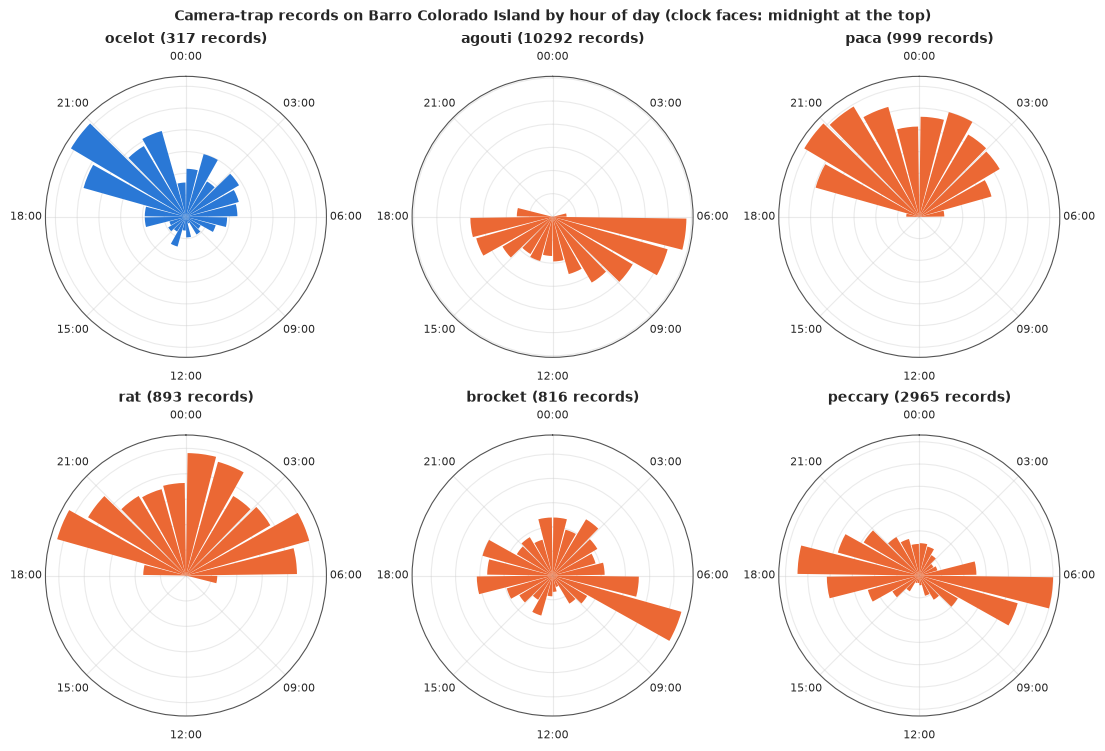

In [19]:
data.describe("bci_camera_trap")
cam_all = data.load("bci_camera_trap")
SPECIES = ["ocelot", "agouti", "paca", "rat", "brocket", "peccary"]
cam = cam_all[cam_all.species.isin(SPECIES)].copy()
cam["th"] = TWO_PI * cam.time                    # 0 = midnight, pi = noon
xs = {s_: cam.th[cam.species == s_].to_numpy() for s_ in SPECIES}
print(pd.DataFrame({"records": {s_: len(v) for s_, v in xs.items()},
                    "mean time": {s_: f"{(np.rad2deg(mean_resultant(v)[0]) % 360) / 15:.1f} h" for s_, v in xs.items()},
                    "R": {s_: mean_resultant(v)[1] for s_, v in xs.items()}}).round(2).T.to_string())

fig, axes = plt.subplots(2, 3, figsize=(11, 7.4), subplot_kw={"projection": "polar"})
for ax, s_ in zip(axes.ravel(), SPECIES):
    cnt, edges = np.histogram(xs[s_], bins=24, range=(0, TWO_PI))
    ax.bar(edges[:-1] + np.pi / 24, cnt / cnt.sum(), width=TWO_PI / 24 * 0.9, color=BLUE if s_ == "ocelot" else ORANGE)
    clockface(ax)
    ax.set_yticklabels([])
    ax.set_title(f"{s_} ({len(xs[s_])} records)", fontsize=10)
fig.suptitle("Camera-trap records on Barro Colorado Island by hour of day (clock faces: midnight at the top)", fontsize=10);

The **ocelot** is mostly nocturnal, with a peak in the evening (19:00-21:00) and few daytime records;
the **agouti** is diurnal with two peaks, after dawn and before dusk; the **paca** and the spiny **rat**
are nocturnal; the red **brocket** deer is about at all hours with a peak at dawn; the collared
**peccary** is active by day with peaks at dawn and dusk. The mean times and $\bar R$ in the table are
again poor summaries: the agouti's two peaks give a "mean time" of 11:00, when it is less active than
at 07:00 or 17:00, and the peccary's two peaks nearly cancel ($\bar R$ = 0.09) to a meaningless mean
time of 21:00.

### A von Mises mixture, the obvious way - and what goes wrong

A flexible activity density is a mixture of von Mises distributions. Fitted the obvious way - means
uniform on $(-\pi, \pi)$, where $\pm\pi$ is **noon**, concentrations and weights with standard priors - to the
agouti's 10,292 records with two components:

In [20]:
def vm_mix_density(mu, kappa, w, at):
    """Density of a von Mises mixture on the grid `at`; parameters (..., K)."""
    return (w[..., None] * np.exp(kappa[..., None] * (np.cos(at - mu[..., None]) - 1))
            / (TWO_PI * special.i0e(kappa[..., None]))).sum(-2)


def max_rhat(arr):
    """Largest r_hat over the trailing dimensions of a (chain, draw, ...) array."""
    dims = ("chain", "draw") + tuple(f"d{i}" for i in range(arr.ndim - 2))
    return float(np.nanmax(az.rhat(xr.Dataset({"v": (dims, arr)}))["v"].values))


G = 256
cgrid = np.arange(G) * TWO_PI / G                    # clock grid, 0 = midnight
x_ag = wrap(xs["agouti"])
with pm.Model() as m_agouti_uniform:
    mu = pm.Uniform("mu", -np.pi, np.pi, shape=2)
    kappa = pm.Gamma("kappa", 2.0, 0.5, shape=2)
    w = pm.Dirichlet("w", np.ones(2))
    pm.Mixture("y", w=w, comp_dists=pm.VonMises.dist(mu=mu, kappa=kappa), observed=x_ag)
    idata_ag_u = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
post = {v: idata_ag_u.posterior[v].values for v in ("mu", "kappa", "w")}
tab = pd.DataFrame({
    "peak times (h)": [", ".join(f"{(np.rad2deg(m_) % 360) / 15:.1f}" for m_ in mean_resultant(post["mu"][c], axis=0)[0])
                       for c in range(4)],
    "kappa": [np.round(post["kappa"][c].mean(0), 1).tolist() for c in range(4)],
    "weights": [np.round(post["w"][c].mean(0), 2).tolist() for c in range(4)],
    "mean logp": idata_ag_u.sample_stats["logp"].values.mean(1).round(1),
    "divergences": idata_ag_u.sample_stats["diverging"].values.sum(1)})
print(tab.to_string())
dens_u = vm_mix_density(post["mu"], post["kappa"], post["w"], cgrid)
print(f"max r_hat of the parameters: {max(max_rhat(post[v]) for v in post):.2f}; "
      f"max r_hat of the density on a 256-point grid: {max_rhat(dens_u):.2f}")

  peak times (h)        kappa       weights  mean logp  divergences
0      8.3, 15.7   [5.7, 4.2]  [0.58, 0.42]   -13168.7            0
1     17.3, 12.0  [30.9, 1.3]  [0.13, 0.87]   -15555.2            0
2      15.7, 8.3   [4.2, 5.7]  [0.43, 0.57]   -13168.7            0
3      8.3, 15.7   [5.7, 4.2]  [0.58, 0.42]   -13168.7            0
max r_hat of the parameters: 2.41; max r_hat of the density on a 256-point grid: 1.53


Two different things went wrong, and only one of them matters:

* **Label switching.** Some chains call the morning peak "component 1", others "component 2". That
  alone makes every parameter's $\hat R$ large, but it is harmless: the *density* is the same whatever the
  labels. The right check for anything label-invariant (the density, an overlap, an activity level) is
  $\hat R$ of that quantity itself.
* **A chain stuck at the seam.** One chain has a component pressed against $\pm\pi$ = **noon** (a peak
  time of 12.0 h), with a much lower log density: the wall of the uniform prior again, now inside a
  mixture. This one is not harmless - the density itself disagrees between chains ($\hat R$ of the density
  well above 1.01) - and again there are **zero divergences**.

The cure is the same as in Part C: give each component its natural parameters,
$\eta_k = \kappa_k(\cos\mu_k, \sin\mu_k) \sim N(0, 3^2 I)$, so each component's mean is a point in the plane
with no seam and its concentration is that point's distance from the origin. We fit two and three
components to the ocelot and the agouti and check $\hat R$ both ways.

In [21]:
def fit_vm_mixture(x, K):
    with pm.Model() as m:
        eta = pm.Normal("eta", 0, 3, shape=(K, 2))
        pm.Deterministic("mu", pt.arctan2(eta[:, 1], eta[:, 0]))
        pm.Deterministic("kappa", pt.sqrt(pt.sum(eta ** 2, axis=1)))
        w = pm.Dirichlet("w", np.ones(K))
        pm.Mixture("y", w=w, comp_dists=pm.VonMises.dist(mu=m["mu"], kappa=m["kappa"]), observed=wrap(x))
        return pm.sample(random_seed=RANDOM_SEED, progressbar=False)


rows, loo_act = [], {s_: {} for s_ in ("ocelot", "agouti")}
for s_ in ("ocelot", "agouti"):
    for K in (2, 3):
        t0 = time.time()
        idd = fit_vm_mixture(xs[s_], K)
        p_ = {v: idd.posterior[v].values for v in ("mu", "kappa", "w")}
        rows.append({"species": s_, "components": K, "seconds": time.time() - t0,
                     "divergences": int(idd.sample_stats["diverging"].sum()),
                     "max r_hat, parameters": max(max_rhat(p_[v]) for v in p_),
                     "max r_hat, density": max_rhat(vm_mix_density(p_["mu"], p_["kappa"], p_["w"], cgrid))})
        ex = az.extract(idd, var_names=["mu", "kappa", "w"], num_samples=1000, random_seed=1)
        mu_, k_, w_ = (ex[v].transpose("sample", ...).values for v in ("mu", "kappa", "w"))
        ll = special.logsumexp(np.log(w_)[:, None, :] + k_[:, None, :] * (np.cos(xs[s_][None, :, None] - mu_[:, None, :]) - 1)
                               - np.log(TWO_PI * special.i0e(k_))[:, None, :], axis=2)
        loo_act[s_][f"von Mises mixture, K = {K}"] = loo_from_ll(ll)
        if s_ == "agouti" and K == 3:
            agouti_mix3 = (mu_, k_, w_)
        del idd, ll
print(pd.DataFrame(rows).round(3).to_string(index=False))

species  components  seconds  divergences  max r_hat, parameters  max r_hat, density
 ocelot           2    1.277            0                  1.004               1.003
 ocelot           3    1.846            0                  1.334               1.006
 agouti           2    6.480            0                  1.533               1.004
 agouti           3   15.382            0                  2.419               1.007


With natural parameters no chain is stuck and there are no divergences. The parameters still have
$\hat R$ well above 1 for three components (and for the agouti with two) because the chains label the
components differently, but the density agrees across chains ($\hat R \le 1.01$). We could impose an order
on the components to stop the switching, but "ordered" on a circle is itself ambiguous (ordered from
where?), and nothing we want to report depends on the labels.

### A label-free alternative: the log-Fourier density

If the labels are a nuisance, use a model without labels. Any smooth positive density on the circle
can be written as the exponential of a Fourier series:

$$\log f(\theta) = \sum_{k=1}^{K} \big(a_k\cos k\theta + b_k\sin k\theta\big) - \log Z(a, b).$$

The von Mises is the case $K = 1$; with more harmonics this is an exponential family whose sufficient
statistics are the **trigonometric moments** $\sum_i \cos k\theta_i$, $\sum_i \sin k\theta_i$. So the
log-likelihood of all 10,292 agouti records costs as much as that of one: $\sum_k (a_k C_k + b_k S_k) - n\log Z$.
$Z$ is an integral of a smooth periodic function, for which the plain average over an equally spaced
grid (256 points here) is accurate to many digits. We use $K = 16$ harmonics with a smoothness prior
$a_k, b_k \sim N(0, (\tau/k)^2)$ - higher harmonics shrink harder - and a half-normal(2) prior on each
species' $\tau$, all six species in one model.

In [22]:
KH = 16
kk = np.arange(1, KH + 1)
Cg, Sg = np.cos(np.outer(cgrid, kk)), np.sin(np.outer(cgrid, kk))
n_sp = np.array([len(xs[s_]) for s_ in SPECIES])
Csum = np.array([np.cos(np.outer(xs[s_], kk)).sum(0) for s_ in SPECIES])     # trigonometric moments
Ssum = np.array([np.sin(np.outer(xs[s_], kk)).sum(0) for s_ in SPECIES])
dth_g = TWO_PI / G
# check the grid integral: a von Mises with kappa = 18 (sharper than any activity peak here)
vm18 = np.exp(18 * (np.cos(cgrid) - 1))
print(f"grid normaliser vs exact for kappa = 18: {vm18.sum() * dth_g:.12f} vs {TWO_PI * special.i0e(18):.12f}")

t0 = time.time()
with pm.Model(coords={"species": SPECIES, "k": kk, "grid": np.arange(G)}) as m_fourier:
    tau = pm.HalfNormal("tau", 2.0, dims="species")
    za = pm.Normal("za", 0, 1, dims=("species", "k"))
    zb = pm.Normal("zb", 0, 1, dims=("species", "k"))
    a = pm.Deterministic("a", za * tau[:, None] / kk, dims=("species", "k"))
    b = pm.Deterministic("b", zb * tau[:, None] / kk, dims=("species", "k"))
    lg = pt.dot(a, Cg.T) + pt.dot(b, Sg.T)
    logZ = pt.logsumexp(lg, axis=1) + np.log(dth_g)
    pm.Potential("ll", pt.sum(a * Csum + b * Ssum) - pt.sum(n_sp * logZ))
    pm.Deterministic("f", pt.exp(lg - logZ[:, None]), dims=("species", "grid"))
    idata_f = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(f"log-Fourier model, 6 species: {time.time() - t0:.0f} s; divergences "
      f"{int(idata_f.sample_stats['diverging'].sum())}; max r_hat of tau {az.rhat(idata_f, var_names=['tau'])['tau'].max().item():.3f}; "
      f"max r_hat of the densities {max_rhat(idata_f.posterior['f'].values):.3f}")

fd = az.extract(idata_f, var_names=["f"], num_samples=1000, random_seed=1).transpose("sample", ...).values   # S, species, G
Ad = az.extract(idata_f, var_names=["a"], num_samples=1000, random_seed=1).transpose("sample", ...).values
Bd = az.extract(idata_f, var_names=["b"], num_samples=1000, random_seed=1).transpose("sample", ...).values
logZd = np.log(np.exp(Ad @ Cg.T + Bd @ Sg.T).sum(-1) * dth_g)
for j, s_ in enumerate(SPECIES):
    if s_ in loo_act:
        x = xs[s_]
        ll = Ad[:, j] @ np.cos(np.outer(x, kk)).T + Bd[:, j] @ np.sin(np.outer(x, kk)).T - logZd[:, j:j + 1]
        loo_act[s_][f"log-Fourier, K = {KH}"] = loo_from_ll(ll)
for s_ in loo_act:
    print(f"--- {s_}")
    print(az.compare(loo_act[s_], round_to=1)[["rank", "elpd", "elpd_diff", "dse", "p"]].to_string())

grid normaliser vs exact for kappa = 18: 0.595057202578 vs 0.595057202578


log-Fourier model, 6 species: 5 s; divergences 0; max r_hat of tau 1.003; max r_hat of the densities 1.005


--- ocelot
                          rank   elpd  elpd_diff  dse     p
von Mises mixture, K = 3     0 -526.4        0.0  0.0   6.9
von Mises mixture, K = 2     1 -527.5       -1.1  2.1   4.3
log-Fourier, K = 16          2 -528.4       -2.0  1.6  12.3
--- agouti
                          rank     elpd  elpd_diff   dse     p
log-Fourier, K = 16          0 -11928.2        0.0   0.0  26.8
von Mises mixture, K = 3     1 -12485.4     -557.1  28.6  12.9
von Mises mixture, K = 2     2 -13165.8    -1237.6  41.3   6.4


The log-Fourier model samples all six species at once in a few seconds, with no divergences and no
labels to switch. For the ocelot (317 records) all three models are within 2 nats of each other: there
is not enough information to separate them. For the agouti the log-Fourier density beats the
three-component mixture by about 560 ± 30 nats: with 10,000 records the agouti's day has more structure
than three von Mises bumps can hold (the peaks are not quite von Mises-shaped, and there is detail in
between). A mixture would need more components - and more label switching - to catch up. The
log-Fourier prior is still a *smoothing* choice (how fast $\tau/k$ shrinks the high harmonics), which
matters for one of the quantities below. We use it for all species from here on.

### How much does the ocelot's day overlap with its prey's?

The **coefficient of overlap** between two densities is the area under the lower of the two,

$$\Delta = \int_0^{2\pi} \min\{f_1(\theta), f_2(\theta)\}\,d\theta \in [0, 1],$$

1 for identical activity patterns and 0 for animals that are never about at the same time. Each
posterior draw of the two densities gives a draw of $\Delta$. The usual estimator in ecology (Ridout &
Linkie 2009, in the R package *overlap*) plugs in von Mises **kernel** density estimates, with the
bandwidth from a rule of thumb, and gets intervals by bootstrap. We re-implement its $\hat\Delta_4$
(recommended for samples above about 75) in NumPy: the same bandwidth rule (a von Mises concentration
estimated from the first three trigonometric moments), densities on a 512-point grid, and a plain
percentile bootstrap over records (the package's own intervals use a smoothed bootstrap and a bias
adjustment, so ours are only indicative).

In [23]:
def overlap_bandwidth(x, kmax=3):
    """Kernel concentration of the overlap package's rule (Ridout & Linkie 2009)."""
    m_ = np.arctan2(np.sin(x).sum(), np.cos(x).sum())
    est = []
    for k in range(1, kmax + 1):
        tm = np.hypot(np.sin(k * (x - m_)).mean(), np.cos(k * (x - m_)).mean())
        fk = lambda kap: special.ive(k, kap) / special.ive(0, kap) - tm
        est.append(brentq(fk, 1e-4, 345) if fk(1e-4) * fk(345) <= 0 else 0.0)
    kh = max(est)
    return (3 * len(x) * kh ** 2 * special.ive(2, 2 * kh) * np.exp(2 * kh)
            / (4 * np.sqrt(np.pi) * (special.ive(0, kh) * np.exp(kh)) ** 2)) ** 0.4


kgrid = np.arange(512) * TWO_PI / 512


def kernel_density(x, nu):
    """von Mises kernel density of x (radians) on kgrid, concentration nu, computed in chunks."""
    out = np.zeros(len(kgrid))
    for i in range(0, len(x), 2000):
        out += np.exp(nu * (np.cos(kgrid[:, None] - x[None, i:i + 2000]) - 1)).sum(1)
    return out / (len(x) * TWO_PI * special.ive(0, nu))


def interp_circ(dens, x):
    return np.interp(np.mod(x, TWO_PI), np.r_[kgrid, TWO_PI], np.r_[dens, dens[0]])


def dhat4(x, y):
    fx, fy = kernel_density(x, overlap_bandwidth(x)), kernel_density(y, overlap_bandwidth(y))
    return 0.5 * (np.minimum(1, interp_circ(fy, x) / interp_circ(fx, x)).mean()
                  + np.minimum(1, interp_circ(fx, y) / interp_circ(fy, y)).mean())


# prior predictive of Delta: two independent draws of the log-Fourier prior
n_pr = 2000
tau_pr = np.abs(rng.normal(0, 2, size=(n_pr, 2)))
a_pr = rng.normal(size=(n_pr, 2, KH)) * tau_pr[..., None] / kk
b_pr = rng.normal(size=(n_pr, 2, KH)) * tau_pr[..., None] / kk
lg_pr = a_pr @ Cg.T + b_pr @ Sg.T
f_pr = np.exp(lg_pr - special.logsumexp(lg_pr, axis=-1, keepdims=True)) / dth_g
delta_prior = np.minimum(f_pr[:, 0], f_pr[:, 1]).sum(-1) * dth_g

rng_b = np.random.default_rng(RANDOM_SEED)
N_BOOT = 200
ov_rows, delta_post = [], {}
for j, s_ in enumerate(SPECIES[1:], start=1):
    d_post = np.minimum(fd[:, 0], fd[:, j]).sum(-1) * dth_g
    delta_post[s_] = d_post
    x, y = xs["ocelot"], xs[s_]
    boot = np.array([dhat4(rng_b.choice(x, len(x)), rng_b.choice(y, len(y))) for _ in range(N_BOOT)])
    lo_, hi_ = np.quantile(d_post, [0.03, 0.97])
    ov_rows.append({"prey": s_, "posterior median": np.median(d_post), "94% from": lo_, "to": hi_,
                    "kernel Dhat4": dhat4(x, y), "bootstrap 3%": np.quantile(boot, 0.03),
                    "bootstrap 97%": np.quantile(boot, 0.97)})
ov = pd.DataFrame(ov_rows).set_index("prey")
print(ov.round(3).to_string())
print(f"prior of Delta between two independent prior densities: median {np.median(delta_prior):.2f}, "
      f"94% interval {np.quantile(delta_prior, 0.03):.2f}-{np.quantile(delta_prior, 0.97):.2f}")

         posterior median  94% from     to  kernel Dhat4  bootstrap 3%  bootstrap 97%
prey                                                                                 
agouti              0.303     0.257  0.350         0.300         0.259          0.338
paca                0.662     0.615  0.708         0.703         0.648          0.741
rat                 0.701     0.655  0.747         0.747         0.696          0.778
brocket             0.750     0.697  0.799         0.772         0.707          0.807
peccary             0.655     0.611  0.701         0.667         0.624          0.706
prior of Delta between two independent prior densities: median 0.30, 94% interval 0.02-0.82


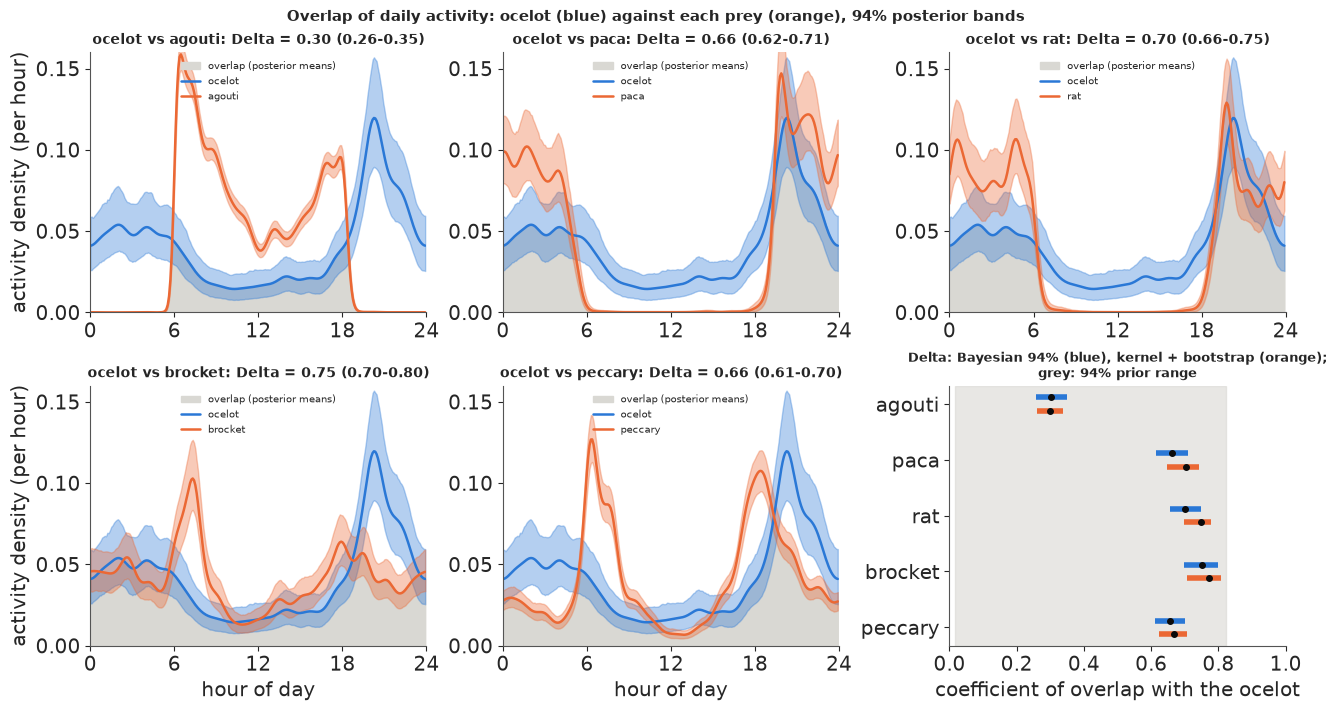

In [24]:
hrs = cgrid / TWO_PI * 24
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, s_ in zip(axes.ravel(), SPECIES[1:]):
    j = SPECIES.index(s_)
    m_oc, m_pr = fd[:, 0].mean(0) * TWO_PI / 24, fd[:, j].mean(0) * TWO_PI / 24     # per hour
    ax.fill_between(hrs, np.minimum(m_oc, m_pr), color=LIGHT, label="overlap (posterior means)")
    for arr, c, lab in ((fd[:, 0], BLUE, "ocelot"), (fd[:, j], ORANGE, s_)):
        lo_, hi_ = np.quantile(arr * TWO_PI / 24, [0.03, 0.97], axis=0)
        ax.fill_between(hrs, lo_, hi_, color=c, alpha=0.35)
        ax.plot(hrs, arr.mean(0) * TWO_PI / 24, color=c, lw=1.8, label=lab)
    r_ = ov.loc[s_]
    ax.set_title(f"ocelot vs {s_}: Delta = {r_['posterior median']:.2f} ({r_['94% from']:.2f}-{r_['to']:.2f})", fontsize=10)
    ax.set(xticks=range(0, 25, 6), xlim=(0, 24), ylim=(0, 0.16))
    ax.legend(fontsize=7, loc="upper center")
ax = axes.ravel()[-1]
ypos = np.arange(len(ov))[::-1]
for yy, (s_, r_) in zip(ypos, ov.iterrows()):
    ax.plot([r_["94% from"], r_["to"]], [yy + 0.12] * 2, color=BLUE, lw=4, solid_capstyle="butt")
    ax.plot(r_["posterior median"], yy + 0.12, "o", color=INK, ms=4)
    ax.plot([r_["bootstrap 3%"], r_["bootstrap 97%"]], [yy - 0.12] * 2, color=ORANGE, lw=4, solid_capstyle="butt")
    ax.plot(r_["kernel Dhat4"], yy - 0.12, "o", color=INK, ms=4)
ax.axvspan(np.quantile(delta_prior, 0.03), np.quantile(delta_prior, 0.97), color=LIGHT, alpha=0.6, zorder=0)
ax.set(yticks=ypos, yticklabels=ov.index, xlim=(0, 1), xlabel="coefficient of overlap with the ocelot",
       xticks=np.arange(0, 1.01, 0.2))
ax.set_title("Delta: Bayesian 94% (blue), kernel + bootstrap (orange);\ngrey: 94% prior range", fontsize=9)
for ax in axes[1, :2]:
    ax.set_xlabel("hour of day")
for ax in axes[:, 0]:
    ax.set_ylabel("activity density (per hour)")
fig.suptitle("Overlap of daily activity: ocelot (blue) against each prey (orange), 94% posterior bands", fontsize=11);

Reading the panels:

* The ocelot and the **agouti** overlap least (0.30): the agouti's two daytime peaks sit where the
  ocelot is quiet, and what overlap there is comes around dawn and dusk.
* The overlap is largest with the **brocket** (0.75), which is about at all hours, and with the
  nocturnal spiny **rat** (0.70) and **paca** (0.66); the day-active **peccary** overlaps about as much as
  the paca (0.66) because the ocelot's evening peak meets its dusk peak.
* The Bayesian and kernel estimates tell the same story. For the agouti they agree (0.30); for the other
  prey the posterior medians are 0.01-0.05 *below* the kernel $\hat\Delta_4$, and the posterior intervals
  are about as wide as the bootstrap intervals (0.08-0.10). The difference is smoothing: the kernel rule
  of thumb and our smoothness prior are different amounts of smoothing, and smoother densities overlap
  more. Neither is "the truth"; the Bayesian version at least makes the smoothing an explicit, checkable
  prior. The prior itself says little about $\Delta$: two independent draws from it overlap by anything
  from 0.02 to 0.82 (grey), so the data, not the prior, set these intervals.

The same overlap on a clock face, for the pair with the least and one with the most overlap:

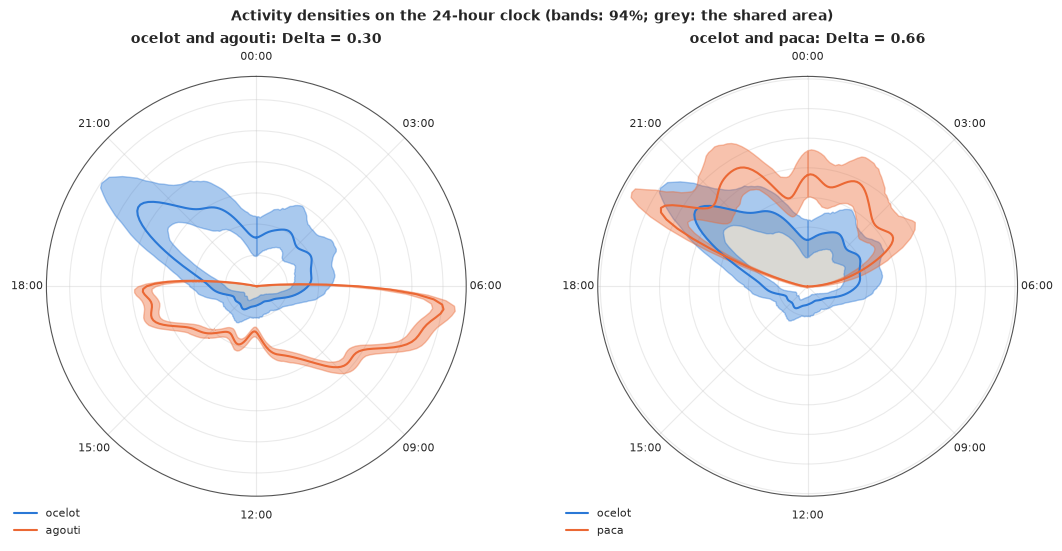

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.4), subplot_kw={"projection": "polar"})
for ax, s_ in zip(axes, ("agouti", "paca")):
    j = SPECIES.index(s_)
    clockface(ax)
    th_c = np.r_[cgrid, cgrid[0]]
    m_oc, m_pr = fd[:, 0].mean(0), fd[:, j].mean(0)
    ax.fill_between(th_c, 0, np.r_[np.minimum(m_oc, m_pr), min(m_oc[0], m_pr[0])], color=LIGHT, lw=0)
    for arr, c, lab in ((fd[:, 0], BLUE, "ocelot"), (fd[:, j], ORANGE, s_)):
        lo_, hi_ = np.quantile(arr, [0.03, 0.97], axis=0)
        ax.fill_between(th_c, np.r_[lo_, lo_[0]], np.r_[hi_, hi_[0]], color=c, alpha=0.4)
        ax.plot(th_c, np.r_[arr.mean(0), arr.mean(0)[0]], color=c, lw=1.5, label=lab)
    ax.set_yticklabels([])
    ax.legend(loc="lower left", bbox_to_anchor=(-0.1, -0.12), fontsize=8)
    ax.set_title(f"ocelot and {s_}: Delta = {ov.loc[s_, 'posterior median']:.2f}", fontsize=10)
fig.suptitle("Activity densities on the 24-hour clock (bands: 94%; grey: the shared area)", fontsize=10);

### Activity level

Rowcliffe et al. (2014) turned the same curves into an estimate of the **fraction of the day an animal
is active**: if at the peak of the activity curve the whole population is active, then the activity
level is the ratio of the mean to the maximum of the density, $1 / (2\pi \max_\theta f(\theta))$. Each
posterior draw gives one value. This is the quantity mentioned above that depends on the *height of the
peak*, which is exactly what a smoothing prior (or a kernel bandwidth) controls.

In [26]:
act = 1 / (TWO_PI * fd.max(-1))
act_tab = pd.DataFrame({"median": np.median(act, 0), "94% from": np.quantile(act, 0.03, 0),
                        "to": np.quantile(act, 0.97, 0)}, index=SPECIES)
print(act_tab.round(3).to_string())
f_mix3 = vm_mix_density(*agouti_mix3, cgrid)
act_mix3 = 1 / (TWO_PI * f_mix3.max(-1))
print(f"agouti from the 3-component mixture: median {np.median(act_mix3):.3f} "
      f"(94%: {np.quantile(act_mix3, 0.03):.3f}-{np.quantile(act_mix3, 0.97):.3f}); overlap with the ocelot "
      f"{np.median(np.minimum(fd[:, 0], f_mix3).sum(-1) * dth_g):.3f}")
print(f"total run time {time.time() - T_START:.0f} s")

         median  94% from     to
ocelot    0.338     0.257  0.433
agouti    0.262     0.247  0.278
paca      0.279     0.232  0.323
rat       0.314     0.263  0.366
brocket   0.400     0.327  0.484
peccary   0.326     0.292  0.364
agouti from the 3-component mixture: median 0.255 (94%: 0.246-0.264); overlap with the ocelot 0.332
total run time 187 s


The ocelot is active about a third of the day (with a wide interval, 0.26-0.43, from 317 records), the
agouti about a quarter. For the agouti the three-component mixture gives almost the same activity level
(0.255 against 0.262) and overlap with the ocelot (0.33 against 0.30): here the choice of density model
moves the answers by less than their uncertainty, although LOO clearly separated the models. That need
not hold for a smaller sample, where the smoothing prior decides how high a peak may be. And the
activity level assumes a fully active population at the peak, which camera times alone cannot check.

## Summary

* **Angles need vector averages.** The arithmetic mean of wind directions fell between 169 and 209
  degrees in every month; the circular mean moved from 110 to 275 degrees, and in December and
  January its mean resultant length was 0.02-0.04, i.e. no meaningful mean direction at all. Always
  report $\bar R$ with a mean direction, and remember that $\bar R$ is biased upwards in small samples
  (the "patternless" Oklahoma earthquakes gave 0.02, against 0.016 expected by chance).
* **The von Mises is an exponential family - use it.** In natural parameters
  $\eta = \kappa(\cos\mu, \sin\mu)$ the log-likelihood is concave. A regression with a canonical link
  (linear predictors for $\eta$) has a single mode, no walls and no wrapping, sampled cleanly every time,
  and fitted the direction-speed relation better than the tan-half link (by about 240 nats of LOO).
* **Two traps give zero divergences.** A uniform prior on an angle puts a wall at $\pm\pi$ (a chain was
  pinned there, $\hat R$ 2.4); the tan-half link has a genuine second mode where it becomes a step. Only
  $\hat R$ and per-chain summaries show them. The same wall broke an activity mixture (a chain stuck at
  "noon").
* **Circular predictors are easy: use harmonics.** Hour of day and day of year entered as cosines and
  sines. A mixture of two wind regimes with time-dependent gates beat the single von Mises and the
  projected normal regressions by about 1,560 nats of LOO and by 916 ± 75 nats on the held-out year
  2023; rose diagrams with predictive bands and circular PIT showed why (two lobes at the transition
  hours) and what still misfits (peaks sharper than the model).
* **Label switching is a diagnostic problem, not an inferential one** when the target is
  label-invariant: check $\hat R$ on the density. A log-Fourier density fitted through its trigonometric
  moments has no labels at all, fits six species in seconds and beat a three-component mixture for the
  agouti by about 560 nats of LOO; its smoothing prior is still a choice to check.
* **Overlap with honest uncertainty.** The ocelot's activity overlapped least with the diurnal agouti
  (Delta 0.30) and most with the brocket, spiny rat and paca (0.66-0.75). Posterior intervals matched
  the bootstrap in width and sat 0-0.05 below the kernel estimate - a smoothing difference, made explicit
  by the prior.

## Try it yourself

1. **Use the speed.** The projected normal treats the direction as the angle of a latent vector - and
   for wind the vector exists: $(u, v) = -\text{speed}\,(\sin d, \cos d)$ for a wind from direction $d$. Model the observed
   wind vector with a bivariate normal (or a bivariate t) whose mean depends on hour and season, derive
   the implied distribution of the direction, and compare its 2023 log score for the direction with the
   mixture's. What happens to the calms?
2. **Wrapped Cauchy regimes.** Replace the von Mises components of the wind mixture by wrapped Cauchy
   components (mean direction as atan2 of a linear predictor, $\rho$ through a logistic link). Heavier
   tails might absorb the stray directions that made the von Mises regimes too wide. Do LOO and the
   rose diagrams agree?
3. **Smoothing and activity levels.** Refit the log-Fourier model with a slower-decaying prior
   ($\tau/\sqrt{k}$) or more harmonics, and recompute the activity level of the agouti and its overlap
   with the ocelot. Then compute both from the three-component mixture draws. How much of the
   difference between methods is smoothing, and which answer would you report to an ecologist?